# Mumbai Affordable Restaurant Recommendation and Analytics System

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This notebook will guide you through building a Python-based content recommendation system for affordable and well-rated restaurants in specific Mumbai areas. We'll cover data loading, cleaning, feature engineering, exploratory data analysis, recommendation model development, and export of results for Tableau.

## SECTION 1: INSTALL AND IMPORT LIBRARIES

First, we'll install any necessary libraries and import all the required Python packages. We'll also configure Pandas and Seaborn for better data display and plotting.

In [73]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn scikit-learn joblib tqdm

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import os
import re
import json
from pathlib import Path
from google.colab import files

print("Libraries installed and imported successfully!")

# Set Pandas display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set Seaborn chart style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Pandas display options and Seaborn chart style set.")

Libraries installed and imported successfully!
Pandas display options and Seaborn chart style set.


## SECTION 2: CREATE PROJECT DIRECTORIES

We'll create a structured set of directories for our project. This helps in organizing our data, notebooks, models, and outputs efficiently.

In [74]:
from pathlib import Path
import os

project_root = 'mumbai-restaurant-recommender'

# Define the directory structure
dirs = [
    'data',
    'notebooks',
    'output',
    'models',
    'images',
    'tableau'
]

# Create the root directory
Path(project_root).mkdir(parents=True, exist_ok=True)

# Create subdirectories
for d in dirs:
    Path(f"{project_root}/{d}").mkdir(parents=True, exist_ok=True)

# Create placeholder files for initial project structure
Path(f"{project_root}/README.md").touch()
Path(f"{project_root}/requirements.txt").touch()
Path(f"{project_root}/dataset_source.md").touch()
Path(f"{project_root}/.gitignore").touch()

print(f"Project directory structure created under '{project_root}/':")
for dirpath, dirnames, filenames in os.walk(project_root):
    print(f"|" + "---|" * (dirpath.count(os.sep) - project_root.count(os.sep)) + os.path.basename(dirpath) + ('/' if dirnames else ''))
    for f in filenames:
        print(f"|" + "---|" * (dirpath.count(os.sep) - project_root.count(os.sep) + 1) + f)

Project directory structure created under 'mumbai-restaurant-recommender/':
|mumbai-restaurant-recommender/
|---|dataset_source.md
|---|.gitignore
|---|README.md
|---|requirements.txt
|---|tableau
|---|---|tableau_dashboard_guide.md
|---|---|restaurants_model_data.csv
|---|---|cuisine_summary.csv
|---|---|area_summary.csv
|---|models
|---|---|tfidf_vectorizer.joblib
|---|---|recommender_metadata.json
|---|---|combined_tfidf_vectorizer.joblib
|---|output
|---|images
|---|data
|---|notebooks


## SECTION 3: UPLOAD AND LOAD DATASET

Now, we'll upload your Zomato Mumbai restaurant dataset. The code will automatically detect the uploaded CSV file and attempt to load it, handling both comma-separated and pipe-separated formats. After loading, we'll perform an initial inspection to understand its structure and quality.

In [75]:
from google.colab import files
import pandas as pd # Re-import pandas as it's used directly in this cell

def upload_and_load_csv():
    print("Please upload your Zomato Mumbai restaurant dataset (CSV file).")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded. Please upload a CSV file to proceed.")
        return None

    uploaded_filename = list(uploaded.keys())[0]
    print(f"Uploaded file: {uploaded_filename}")

    df = None
    possible_delimiters = [',', '|', ';', '\t'] # Common delimiters to try

    for sep in possible_delimiters:
        try:
            print(f"Attempting to load with '{sep}' delimiter...")
            temp_df = pd.read_csv(uploaded_filename, sep=sep)
            # If loading is successful and we have more than 1 column, or it's the first try, we might have found the right delimiter
            if len(temp_df.columns) > 1 or sep == ',':
                df = temp_df
                print(f"Dataset loaded successfully with '{sep}' delimiter.")
                break
            else:
                print(f"Loaded with '{sep}' but only one column found. Trying other delimiters.")
        except pd.errors.ParserError as e:
            print(f"ParserError with '{sep}' delimiter: {e}")
        except Exception as e:
            print(f"An unexpected error occurred with '{sep}' delimiter: {e}")
            break # Break for other unexpected errors

    if df is None:
        print("Failed to load dataset with any of the common delimiters. Please check the file's format.")
        return None

    return df

df_raw = upload_and_load_csv()

if df_raw is not None:
    print("\n--- Initial Data Inspection ---")
    print("\nFirst 5 rows of the dataset:")
    display(df_raw.head())

    print(f"\nDataset shape: {df_raw.shape}")

    print("\nColumn names:")
    print(df_raw.columns.tolist())

    print("\nData types:")
    print(df_raw.info())

    print("\nMemory usage:")
    print(df_raw.memory_usage(deep=True).sum())

    print("\nMissing values (count and percentage):")
    missing_counts = df_raw.isnull().sum()
    missing_percentages = (df_raw.isnull().sum() / len(df_raw)) * 100
    missing_info = pd.DataFrame({'Count': missing_counts, 'Percentage': missing_percentages})
    display(missing_info[missing_info['Count'] > 0].sort_values(by='Count', ascending=False))

    print("\nDuplicate rows count:")
    duplicate_rows = df_raw.duplicated().sum()
    print(f"Number of exact duplicate rows: {duplicate_rows}")
else:
    print("Failed to load dataset. Please re-run the cell and upload a valid CSV file.")

Please upload your Zomato Mumbai restaurant dataset (CSV file).


Saving mumbai_filtered_restaurants (2).csv to mumbai_filtered_restaurants (2) (2).csv
Uploaded file: mumbai_filtered_restaurants (2) (2).csv
Attempting to load with ',' delimiter...
Dataset loaded successfully with ',' delimiter.

--- Initial Data Inspection ---

First 5 rows of the dataset:


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA
0,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337,Juhu
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.7,1842,Juhu
2,Cafe Safar,600,"Chinese,North Indian,Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.0,2797,Andheri
3,145 Bandra,1300,"Mexican,American,Desserts,European,Modern Indian",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.2,1552,Bandra
4,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.5,271,Andheri



Dataset shape: (1782, 13)

Column names:
['NAME', 'PRICE', 'CUSINE_CATEGORY', 'CITY', 'REGION', 'URL', 'PAGE NO', 'CUSINE TYPE', 'TIMING', 'RATING_TYPE', 'RATING', 'VOTES', 'AREA']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   NAME             1782 non-null   object
 1   PRICE            1782 non-null   int64 
 2   CUSINE_CATEGORY  1782 non-null   object
 3   CITY             1782 non-null   object
 4   REGION           1782 non-null   object
 5   URL              1782 non-null   object
 6   PAGE NO          1782 non-null   int64 
 7   CUSINE TYPE      1782 non-null   object
 8   TIMING           1774 non-null   object
 9   RATING_TYPE      1665 non-null   object
 10  RATING           1782 non-null   object
 11  VOTES            1782 non-null   object
 12  AREA             1782 non-null   object
dtypes: int64(2), objec

,Count,Percentage
RATING_TYPE,117,6.57
TIMING,8,0.45



Duplicate rows count:
Number of exact duplicate rows: 0


## SECTION 4: STANDARDIZE COLUMN NAMES

This section focuses on cleaning and standardizing the column names in our dataset. We'll remove leading/trailing spaces, convert names to uppercase, replace multiple spaces with underscores, and remove special characters. After this general cleaning, we'll map the original column names to a set of predefined standard names, handling common variations. Finally, we'll validate that all essential columns are present after mapping.

In [76]:
import re # Import the regular expression module

def clean_col_name(col_name):
    """Cleans a column name by removing spaces, special characters, and converting to uppercase."""
    col_name = str(col_name).strip() # Remove leading/trailing spaces
    col_name = col_name.upper() # Convert to uppercase
    col_name = re.sub(r'\s+', '_', col_name) # Replace spaces with underscores
    col_name = re.sub(r'[^A-Z0-9_]', '', col_name) # Remove special characters except underscores
    return col_name

# Apply cleaning to all column names
df = df_raw.copy()
df.columns = [clean_col_name(col) for col in df.columns]

print("Cleaned column names:")
print(df.columns.tolist())

# Define the mapping from likely source column names to standard names
column_mapping = {
    'NAME': 'RESTAURANT_NAME',
    'RESTAURANT_NAME': 'RESTAURANT_NAME',
    'PRICE': 'PRICE',
    'COST_FOR_TWO': 'PRICE',
    'CUSINE_CATEGORY': 'CUISINES',
    'CUISINES': 'CUISINES',
    'CITY': 'CITY',
    'REGION': 'REGION',
    'CUSINE_TYPE': 'RESTAURANT_TYPE',
    'CUSINE_TYPE_': 'RESTAURANT_TYPE', # Handle potential double underscore from cleaning
    'RESTAURANT_TYPE': 'RESTAURANT_TYPE',
    'RATING': 'RATING',
    'VOTES': 'VOTES',
    'TIMING': 'TIMING',
    'URL': 'URL'
}

# Rename columns using the mapping
# Create a new dictionary that only contains mappings for columns that actually exist in the DataFrame
actual_mapping = {col: column_mapping[col] for col in df.columns if col in column_mapping}

df.rename(columns=actual_mapping, inplace=True)

print("\nColumn names after mapping:")
print(df.columns.tolist())

# Validate essential columns
essential_columns = [
    'RESTAURANT_NAME',
    'PRICE',
    'CUISINES',
    'REGION',
    'RESTAURANT_TYPE',
    'RATING',
    'VOTES'
]

missing_essential_columns = [col for col in essential_columns if col not in df.columns]

if missing_essential_columns:
    print("\nERROR: The following essential columns are missing after standardization:")
    for col in missing_essential_columns:
        print(f"- {col}")
    print("Available columns: ", df.columns.tolist())
    raise SystemExit("Missing essential columns. Please check your dataset or column mapping.")
else:
    print("\nAll essential columns are present in the dataset.")

# Display the first few rows with standardized column names
print("\nDataFrame head after column standardization:")
display(df.head())

Cleaned column names:
['NAME', 'PRICE', 'CUSINE_CATEGORY', 'CITY', 'REGION', 'URL', 'PAGE_NO', 'CUSINE_TYPE', 'TIMING', 'RATING_TYPE', 'RATING', 'VOTES', 'AREA']

Column names after mapping:
['RESTAURANT_NAME', 'PRICE', 'CUISINES', 'CITY', 'REGION', 'URL', 'PAGE_NO', 'RESTAURANT_TYPE', 'TIMING', 'RATING_TYPE', 'RATING', 'VOTES', 'AREA']

All essential columns are present in the dataset.

DataFrame head after column standardization:


,RESTAURANT_NAME,PRICE,CUISINES,CITY,REGION,URL,PAGE_NO,RESTAURANT_TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA
0,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337,Juhu
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.7,1842,Juhu
2,Cafe Safar,600,"Chinese,North Indian,Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.0,2797,Andheri
3,145 Bandra,1300,"Mexican,American,Desserts,European,Modern Indian",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.2,1552,Bandra
4,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.5,271,Andheri


## SECTION 5: DATA CLEANING

This section is dedicated to cleaning the dataset. We'll handle various data quality issues such as duplicate rows, inconsistent values, incorrect data types, and missing data. Each step will involve identifying and rectifying these issues to prepare the data for analysis and model building. We'll also keep track of the number of rows removed at each major cleaning stage.

In [77]:
print("--- Starting Data Cleaning ---")
initial_rows = df.shape[0]
print(f"Initial number of rows: {initial_rows}")

# --- 1. Remove repeated header rows inside the data ---
# This often happens if the CSV was concatenated or had embedded headers.
# We look for rows where 'RESTAURANT_NAME' column value is equal to its column name after standardization
df_cleaned = df[df['RESTAURANT_NAME'] != 'RESTAURANT_NAME'].copy()
rows_removed_headers = initial_rows - df_cleaned.shape[0]
print(f"Rows removed (repeated headers): {rows_removed_headers}")

# --- 2. Remove exact duplicate rows ---
initial_shape_duplicates = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
rows_removed_exact_duplicates = initial_shape_duplicates - df_cleaned.shape[0]
print(f"Rows removed (exact duplicates): {rows_removed_exact_duplicates}")

# --- 3. Remove duplicate restaurant records based on name, region, price, and cuisine ---
initial_shape_restaurant_duplicates = df_cleaned.shape[0]
df_cleaned.drop_duplicates(subset=['RESTAURANT_NAME', 'REGION', 'PRICE', 'CUISINES'], inplace=True)
rows_removed_restaurant_duplicates = initial_shape_restaurant_duplicates - df_cleaned.shape[0]
print(f"Rows removed (restaurant key duplicates): {rows_removed_restaurant_duplicates}")


# --- 4. Clean Restaurant Names ---
# Remove leading/trailing spaces, extra spaces, and common unwanted characters
df_cleaned['RESTAURANT_NAME'] = df_cleaned['RESTAURANT_NAME'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.replace(r'[^a-zA-Z0-9 &\-\_\.]', '', regex=True)
print("Restaurant names cleaned.")

# --- 5. Clean Region Names ---
df_cleaned['REGION'] = df_cleaned['REGION'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
print("Region names cleaned.")

# --- 6. Clean Cuisine values ---
# Standardize to title case and remove extra spaces within each cuisine item
df_cleaned['CUISINES'] = df_cleaned['CUISINES'].astype(str).apply(lambda x: ', '.join([c.strip().title() for c in x.split(',')]) if pd.notna(x) else x)
print("Cuisine values cleaned.")

# --- 7. Clean Restaurant Type values ---
df_cleaned['RESTAURANT_TYPE'] = df_cleaned['RESTAURANT_TYPE'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.title()
print("Restaurant type values cleaned.")

# --- 8. Remove currency symbols and commas from PRICE and convert to numeric ---
initial_price_nulls = df_cleaned['PRICE'].isnull().sum()
df_cleaned['PRICE'] = df_cleaned['PRICE'].astype(str).str.replace('[₹$,]', '', regex=True).str.strip()
# Convert to numeric, coerce errors to NaN for values that can't be converted
df_cleaned['PRICE'] = pd.to_numeric(df_cleaned['PRICE'], errors='coerce')
price_conversion_nulls = df_cleaned['PRICE'].isnull().sum() - initial_price_nulls
print(f"Price column cleaned and converted to numeric. New NaNs from conversion: {price_conversion_nulls}")

# --- 9. Remove text such as /5 from RATING and convert to numeric ---
# Handle the special case 'Veľmi dobré' which appears in the example output
df_cleaned['RATING'] = df_cleaned['RATING'].astype(str).str.replace('/5', '', regex=False).str.strip()
df_cleaned['RATING'] = df_cleaned['RATING'].replace({'Veľmi dobré': '4.0'}) # Assuming this maps to a good rating
df_cleaned['RATING'] = pd.to_numeric(df_cleaned['RATING'], errors='coerce')
print("Rating column cleaned and converted to numeric.")

# --- 10. Convert VOTES to numeric ---
df_cleaned['VOTES'] = df_cleaned['VOTES'].astype(str).str.replace(',', '', regex=False).str.strip()
df_cleaned['VOTES'] = pd.to_numeric(df_cleaned['VOTES'], errors='coerce')
print("Votes column cleaned and converted to numeric.")

# --- 11. Replace missing VOTES with zero ---
df_cleaned['VOTES'] = df_cleaned['VOTES'].fillna(0)
print("Missing votes replaced with zero.")

# --- 12. Remove records where PRICE is zero or negative ---
initial_shape_price_invalid = df_cleaned.shape[0]
df_cleaned = df_cleaned[df_cleaned['PRICE'] > 0]
rows_removed_price_invalid = initial_shape_price_invalid - df_cleaned.shape[0]
print(f"Rows removed (invalid price <= 0): {rows_removed_price_invalid}")

# --- 13. Remove records where RATING is outside 0-5 ---
initial_shape_rating_invalid = df_cleaned.shape[0]
df_cleaned = df_cleaned[(df_cleaned['RATING'] >= 0) & (df_cleaned['RATING'] <= 5)]
rows_removed_rating_invalid = initial_shape_rating_invalid - df_cleaned.shape[0]
print(f"Rows removed (invalid rating outside 0-5): {rows_removed_rating_invalid}")

# --- 14. Remove records missing essential columns: restaurant name, region, cuisine, price or rating ---
initial_shape_missing_essentials = df_cleaned.shape[0]
essential_for_dropna = ['RESTAURANT_NAME', 'REGION', 'CUISINES', 'PRICE', 'RATING']
df_cleaned.dropna(subset=essential_for_dropna, inplace=True)
rows_removed_missing_essentials = initial_shape_missing_essentials - df_cleaned.shape[0]
print(f"Rows removed (missing essential values): {rows_removed_missing_essentials}")

# Calculate total rows removed and final shape
total_rows_removed = initial_rows - df_cleaned.shape[0]
print(f"\nTotal rows removed during cleaning: {total_rows_removed}")
print(f"Final cleaned data shape: {df_cleaned.shape}")

print("--- Data Cleaning Complete ---")

# Display cleaned data info
print("\nCleaned data info:")
print(df_cleaned.info())

print("\nFirst 5 rows of cleaned dataset:")
display(df_cleaned.head())

--- Starting Data Cleaning ---
Initial number of rows: 1782
Rows removed (repeated headers): 0
Rows removed (exact duplicates): 0
Rows removed (restaurant key duplicates): 28
Restaurant names cleaned.
Region names cleaned.
Cuisine values cleaned.
Restaurant type values cleaned.
Price column cleaned and converted to numeric. New NaNs from conversion: 0
Rating column cleaned and converted to numeric.
Votes column cleaned and converted to numeric.
Missing votes replaced with zero.
Rows removed (invalid price <= 0): 5
Rows removed (invalid rating outside 0-5): 356
Rows removed (missing essential values): 0

Total rows removed during cleaning: 389
Final cleaned data shape: (1393, 13)
--- Data Cleaning Complete ---

Cleaned data info:
<class 'pandas.core.frame.DataFrame'>
Index: 1393 entries, 0 to 1781
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RESTAURANT_NAME  1393 non-null   object 
 1   PRICE           

,RESTAURANT_NAME,PRICE,CUISINES,CITY,REGION,URL,PAGE_NO,RESTAURANT_TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA
0,Chin Chin Chu,1800,"Asian, Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.20,337.00,Juhu
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.70,1842.00,Juhu
2,Cafe Safar,600,"Chinese, North Indian, Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.00,2797.00,Andheri
3,145 Bandra,1300,"Mexican, American, Desserts, European, Modern ...",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.20,1552.00,Bandra
4,Angrezi Patiyalaa,1200,"North Indian, Finger Food, American, Mexican, ...",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.50,271.00,Andheri


## SECTION 6: FILTER SELECTED MUMBAI AREAS

In this section, we will focus on filtering the `df_cleaned` DataFrame to retain only those restaurants located in our specified target Mumbai areas: **Andheri, Vile Parle, Juhu, Versova, Santacruz, and Bandra**.

We will implement a robust filtering mechanism that:
- Handles partial matches (e.g., 'Andheri West' should match 'Andheri').
- Is case-insensitive.
- Explicitly **excludes** 'Bandra Kurla Complex' while including 'Bandra'.
- Creates a new, standardized `AREA` column based on these target areas for easier analysis and clearer categorization.

In [78]:
# =========================================================
# COMPLETE CODE: UPLOAD, LOAD, CLEAN AND FILTER DATASET
# =========================================================

import pandas as pd
import re
import os
from google.colab import files

# ---------------------------------------------------------
# 1. Upload the dataset
# ---------------------------------------------------------
print("Please upload your restaurant dataset (CSV or Excel file):")
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file was uploaded.")

filename = list(uploaded.keys())[0]
file_extension = os.path.splitext(filename)[1].lower()

print(f"\nUploaded file: {filename}")

# ---------------------------------------------------------
# 2. Load the dataset
# ---------------------------------------------------------
df = None # Initialize df outside the conditional
if file_extension == '.csv':
    possible_delimiters = [',', '|', ';', '\t'] # Common delimiters to try
    for sep in possible_delimiters:
        try:
            print(f"Attempting to load with '{sep}' delimiter...")
            temp_df = pd.read_csv(filename, sep=sep)
            # If loading is successful and we have more than 1 column, or it's the first try, we might have found the right delimiter
            if len(temp_df.columns) > 1 or sep == possible_delimiters[0]: # Using possible_delimiters[0] for comma
                df = temp_df
                print(f"Dataset loaded successfully with '{sep}' delimiter.")
                break
            else:
                print(f"Loaded with '{sep}' but only one column found. Trying other delimiters.")
        except (pd.errors.ParserError, UnicodeDecodeError) as e:
            print(f"Error with '{sep}' delimiter: {e}. Trying next delimiter...")
    if df is None:
        raise ValueError("Failed to load CSV dataset with any common delimiters.")

elif file_extension in ['.xlsx', '.xls']:
    df = pd.read_excel(filename)

else:
    raise ValueError(
        "Unsupported file format. Please upload a CSV, XLSX or XLS file."
    )

if df is None: # This check handles cases where df might still be None after the loop/conditional
    raise ValueError("Failed to load the dataset.")

print("\nDataset loaded successfully.")
print("Original dataset shape:", df.shape)

# ---------------------------------------------------------
# 3. Clean column names
# ---------------------------------------------------------
df_cleaned = df.copy()

df_cleaned.columns = (
    df_cleaned.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nAvailable columns:")
print(df_cleaned.columns.tolist())

# ---------------------------------------------------------
# 4. Find the location/region column
# ---------------------------------------------------------
possible_region_columns = [
    'REGION',
    'AREA',
    'LOCATION',
    'LOCALITY',
    'ADDRESS',
    'CITY'
]

region_column = None

for column in possible_region_columns:
    if column in df_cleaned.columns:
        region_column = column
        break

if region_column is None:
    raise KeyError(
        "No REGION, AREA, LOCATION, LOCALITY, ADDRESS or CITY column "
        f"was found.\nAvailable columns: {df_cleaned.columns.tolist()}"
    )

print(f"\nColumn used for area filtering: {region_column}")

# ---------------------------------------------------------
# 5. Define the required Mumbai areas
# ---------------------------------------------------------
target_areas = [
    'Andheri',
    'Vile Parle',
    'Juhu',
    'Versova',
    'Santacruz',
    'Bandra'
]

# ---------------------------------------------------------
# 6. Function to standardize area names
# ---------------------------------------------------------
def standardize_area(region):

    if pd.isna(region):
        return 'UNKNOWN'

    region = str(region).strip().lower()

    # Exclude Bandra Kurla Complex because it is not Bandra
    if (
        'bandra kurla complex' in region
        or re.search(r'\bbkc\b', region)
    ):
        return 'OTHER'

    area_patterns = {
        'Vile Parle': r'\bvile[\s-]*parle',
        'Santacruz': r'\bsantacruz|\bsanta[\s-]*cruz',
        'Andheri': r'\bandheri',
        'Juhu': r'\bjuhu',
        'Versova': r'\bversova', # Removed trailing \b for partial match
        'Bandra': r'\bbandra'    # Removed trailing \b for partial match
    }

    for area, pattern in area_patterns.items():
        if re.search(pattern, region, flags=re.IGNORECASE):
            return area

    return 'OTHER'

# ---------------------------------------------------------
# 7. Create standardized AREA column
# ---------------------------------------------------------
df_cleaned['AREA'] = df_cleaned[region_column].apply(
    standardize_area
)

# ---------------------------------------------------------
# 8. Filter only the six selected areas
# ---------------------------------------------------------
df_filtered = df_cleaned[
    df_cleaned['AREA'].isin(target_areas)
].copy()

df_filtered.reset_index(drop=True, inplace=True)

# ---------------------------------------------------------
# 9. Show results
# ---------------------------------------------------------
print("\n------------------------------------")
print("FILTERING RESULTS")
print("------------------------------------")

print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df_filtered.shape)

print("\nNumber of restaurants by area:")
print(df_filtered['AREA'].value_counts())

if df_filtered.empty:
    print(
        "\nNo restaurants were found in the selected areas. "
        "Check the values in the location column:"
    )
    print(df_cleaned[region_column].dropna().astype(str).head(20).tolist())

else:
    print("\nFirst 5 filtered restaurants:")
    display(df_filtered.head())

# ---------------------------------------------------------
# 10. Save and download filtered dataset
# ---------------------------------------------------------
output_filename = 'mumbai_filtered_restaurants.csv'

df_filtered.to_csv(output_filename, index=False)

print(f"\nFile created successfully: {output_filename}")

files.download(output_filename)


Please upload your restaurant dataset (CSV or Excel file):


Saving mumbai_filtered_restaurants (2).csv to mumbai_filtered_restaurants (2) (3).csv

Uploaded file: mumbai_filtered_restaurants (2) (3).csv
Attempting to load with ',' delimiter...
Dataset loaded successfully with ',' delimiter.

Dataset loaded successfully.
Original dataset shape: (1782, 13)

Available columns:
['NAME', 'PRICE', 'CUSINE_CATEGORY', 'CITY', 'REGION', 'URL', 'PAGE NO', 'CUSINE TYPE', 'TIMING', 'RATING_TYPE', 'RATING', 'VOTES', 'AREA']

Column used for area filtering: REGION

------------------------------------
FILTERING RESULTS
------------------------------------
Original dataset shape: (1782, 13)
Filtered dataset shape: (1782, 13)

Number of restaurants by area:
AREA
Andheri       821
Bandra        421
Vile Parle    209
Santacruz     204
Juhu          127
Name: count, dtype: int64

First 5 filtered restaurants:


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA
0,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337,Juhu
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.7,1842,Juhu
2,Cafe Safar,600,"Chinese,North Indian,Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.0,2797,Andheri
3,145 Bandra,1300,"Mexican,American,Desserts,European,Modern Indian",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.2,1552,Bandra
4,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.5,271,Andheri



File created successfully: mumbai_filtered_restaurants.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
print("Total filtered restaurants:", len(df_filtered))

print("\nRestaurants in each area:")
print(df_filtered['AREA'].value_counts())

display(df_filtered.head())

Total filtered restaurants: 1782

Restaurants in each area:
AREA
Andheri       821
Bandra        421
Vile Parle    209
Santacruz     204
Juhu          127
Name: count, dtype: int64


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA
0,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337,Juhu
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.7,1842,Juhu
2,Cafe Safar,600,"Chinese,North Indian,Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.0,2797,Andheri
3,145 Bandra,1300,"Mexican,American,Desserts,European,Modern Indian",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.2,1552,Bandra
4,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.5,271,Andheri


## SECTION 7: FEATURE ENGINEERING

In this section, we will create several new features (columns) that will enhance our ability to analyze and recommend restaurants. These features will categorize restaurants based on price, rating, and popularity, and also calculate a "Weighted Rating" and "Value Score" to provide a more nuanced understanding of a restaurant's appeal. This step is crucial for building a sophisticated recommendation system.

In [80]:
import numpy as np

print("--- Starting Feature Engineering ---")

# Make a copy to avoid modifying the original filtered DataFrame directly if needed later
df_features = df_filtered.copy()

# Standardize column names for consistency with recommendation function
# This is necessary because df_filtered might not have fully standardized names from Section 4
rename_map = {
    'CUSINE_CATEGORY': 'CUISINES',
    'CUSINE TYPE': 'RESTAURANT_TYPE'
}
df_features.rename(columns=rename_map, inplace=True)
print("Standardized 'CUSINE_CATEGORY' to 'CUISINES' and 'CUSINE TYPE' to 'RESTAURANT_TYPE' in df_features.")

# Explicitly ensure critical numerical columns are float, handling potential type inconsistencies
print("Ensuring PRICE, RATING, and VOTES are numeric...")
df_features['PRICE'] = pd.to_numeric(df_features['PRICE'], errors='coerce')
df_features['RATING'] = pd.to_numeric(df_features['RATING'], errors='coerce')
df_features['VOTES'] = pd.to_numeric(df_features['VOTES'], errors='coerce')

# Re-handle potential NaNs introduced by to_numeric, though previous cleaning should have largely addressed this
df_features.dropna(subset=['PRICE', 'RATING', 'VOTES'], inplace=True)
# Replace missing votes with zero again for safety, if any were coerced to NaN here
df_features['VOTES'] = df_features['VOTES'].fillna(0)
print("Numerical columns type confirmed and NaNs handled.")

# A. PRICE_CATEGORY
print("1. Creating PRICE_CATEGORY...")
conditions_price = [
    (df_features['PRICE'] <= 500),
    (df_features['PRICE'] > 500) & (df_features['PRICE'] <= 1000),
    (df_features['PRICE'] > 1000) & (df_features['PRICE'] <= 1500),
    (df_features['PRICE'] > 1500)
]
choices_price = ['Budget', 'Moderate', 'Expensive', 'Premium']
df_features['PRICE_CATEGORY'] = np.select(conditions_price, choices_price, default='Unknown')
print("   PRICE_CATEGORY created.")

# B. RATING_CATEGORY
print("2. Creating RATING_CATEGORY...")
conditions_rating = [
    (df_features['RATING'] >= 4.5),
    (df_features['RATING'] >= 4.0) & (df_features['RATING'] < 4.5),
    (df_features['RATING'] >= 3.5) & (df_features['RATING'] < 4.0),
    (df_features['RATING'] < 3.5)
]
choices_rating = ['Excellent', 'Very Good', 'Good', 'Average']
df_features['RATING_CATEGORY'] = np.select(conditions_rating, choices_rating, default='Unknown')
print("   RATING_CATEGORY created.")

# C. POPULARITY_CATEGORY
print("3. Creating POPULARITY_CATEGORY...")
conditions_popularity = [
    (df_features['VOTES'] < 100),
    (df_features['VOTES'] >= 100) & (df_features['VOTES'] <= 499),
    (df_features['VOTES'] >= 500)
]
choices_popularity = ['Low Popularity', 'Moderately Popular', 'Highly Popular']
df_features['POPULARITY_CATEGORY'] = np.select(conditions_popularity, choices_popularity, default='Unknown')
print("   POPULARITY_CATEGORY created.")

# D. AFFORDABLE_FLAG
print("4. Creating AFFORDABLE_FLAG...")
df_features['AFFORDABLE_FLAG'] = ((df_features['PRICE'] <= 1000) & (df_features['RATING'] >= 3.5))
print("   AFFORDABLE_FLAG created.")

# E. WEIGHTED_RATING (WR)
print("5. Calculating WEIGHTED_RATING...")
# R is the restaurant rating (RATING column)
# v is the number of votes (VOTES column)
# C is the mean rating of filtered restaurants
C = df_features['RATING'].mean()
# m is the 60th percentile of votes
m = df_features['VOTES'].quantile(0.60)

# Define a function for weighted rating to handle division by zero safely
def calculate_weighted_rating(row):
    v = row['VOTES']
    R = row['RATING']
    if (v + m) == 0: # Avoid division by zero if both votes and m are zero
        return C # Fallback to mean rating or R if preferred, C is a good default
    return (v / (v + m)) * R + (m / (v + m)) * C

df_features['WEIGHTED_RATING'] = df_features.apply(calculate_weighted_rating, axis=1).round(2)
print(f"   WEIGHTED_RATING calculated (C={C:.2f}, m={m:.2f}).")

# F. VALUE_SCORE
print("6. Calculating VALUE_SCORE...")
# VALUE_SCORE = (WEIGHTED_RATING / PRICE) * 1000
# Handle potential division by zero for PRICE, though previous cleaning should have removed price=0
df_features['VALUE_SCORE'] = np.where(
    df_features['PRICE'] > 0, # Ensure price is not zero
    (df_features['WEIGHTED_RATING'] / df_features['PRICE']) * 1000,
    0 # Assign 0 if price is not valid
).round(2)
print("   VALUE_SCORE calculated.")

print("--- Feature Engineering Complete ---")

print("\nDataFrame head with new features:")
display(df_features.head())

print("\nValue counts for new categorical features:")
print("\nPRICE_CATEGORY:")
print(df_features['PRICE_CATEGORY'].value_counts())
print("\nRATING_CATEGORY:")
print(df_features['RATING_CATEGORY'].value_counts())
print("\nPOPULARITY_CATEGORY:")
print(df_features['POPULARITY_CATEGORY'].value_counts())
print("\nAFFORDABLE_FLAG:")
print(df_features['AFFORDABLE_FLAG'].value_counts())

print("\nFinal DataFrame info after feature engineering:")
df_features.info()

--- Starting Feature Engineering ---
Standardized 'CUSINE_CATEGORY' to 'CUISINES' and 'CUSINE TYPE' to 'RESTAURANT_TYPE' in df_features.
Ensuring PRICE, RATING, and VOTES are numeric...
Numerical columns type confirmed and NaNs handled.
1. Creating PRICE_CATEGORY...
   PRICE_CATEGORY created.
2. Creating RATING_CATEGORY...
   RATING_CATEGORY created.
3. Creating POPULARITY_CATEGORY...
   POPULARITY_CATEGORY created.
4. Creating AFFORDABLE_FLAG...
   AFFORDABLE_FLAG created.
5. Calculating WEIGHTED_RATING...
   WEIGHTED_RATING calculated (C=3.61, m=109.40).
6. Calculating VALUE_SCORE...
   VALUE_SCORE calculated.
--- Feature Engineering Complete ---

DataFrame head with new features:


,NAME,PRICE,CUISINES,CITY,REGION,URL,PAGE NO,RESTAURANT_TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,AFFORDABLE_FLAG,WEIGHTED_RATING,VALUE_SCORE
0,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.20,337.00,Juhu,Premium,Very Good,Moderately Popular,False,4.06,2.26
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.70,1842.00,Juhu,Expensive,Excellent,Highly Popular,False,4.64,3.09
2,Cafe Safar,600,"Chinese,North Indian,Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.00,2797.00,Andheri,Moderate,Very Good,Highly Popular,True,3.99,6.65
3,145 Bandra,1300,"Mexican,American,Desserts,European,Modern Indian",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.20,1552.00,Bandra,Expensive,Very Good,Highly Popular,False,4.16,3.20
4,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.50,271.00,Andheri,Expensive,Excellent,Moderately Popular,False,4.24,3.53



Value counts for new categorical features:

PRICE_CATEGORY:
PRICE_CATEGORY
Budget       814
Moderate     463
Expensive     86
Premium       47
Name: count, dtype: int64

RATING_CATEGORY:
RATING_CATEGORY
Good         616
Average      487
Very Good    280
Excellent     27
Name: count, dtype: int64

POPULARITY_CATEGORY:
POPULARITY_CATEGORY
Low Popularity        819
Moderately Popular    413
Highly Popular        178
Name: count, dtype: int64

AFFORDABLE_FLAG:
AFFORDABLE_FLAG
True     800
False    610
Name: count, dtype: int64

Final DataFrame info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 1410 entries, 0 to 1781
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NAME                 1410 non-null   object 
 1   PRICE                1410 non-null   int64  
 2   CUISINES             1410 non-null   object 
 3   CITY                 1410 non-null   object 
 4   REGION        

## SECTION 8: EXPLORATORY DATA ANALYSIS (EDA)

In this section, we will perform Exploratory Data Analysis on our `df_features` DataFrame. We will focus on understanding the distributions of the newly created features (`PRICE_CATEGORY`, `RATING_CATEGORY`, `POPULARITY_CATEGORY`, `AFFORDABLE_FLAG`, `WEIGHTED_RATING`, `VALUE_SCORE`), as well as other key variables, to uncover patterns, insights, and potential relationships that can inform our recommendation system.

### Distribution of Categorical Features

Let's visualize the distribution of the newly created categorical features: `PRICE_CATEGORY`, `RATING_CATEGORY`, `POPULARITY_CATEGORY`, and `AFFORDABLE_FLAG` using count plots.

/tmp/ipykernel_824/3776913265.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_features, x='PRICE_CATEGORY', palette='viridis', order=df_features['PRICE_CATEGORY'].value_counts().index)
/tmp/ipykernel_824/3776913265.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_features, x='RATING_CATEGORY', palette='magma', order=df_features['RATING_CATEGORY'].value_counts().index)
/tmp/ipykernel_824/3776913265.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_features, x='POPULARITY_CATEGORY', palette='cividis', 

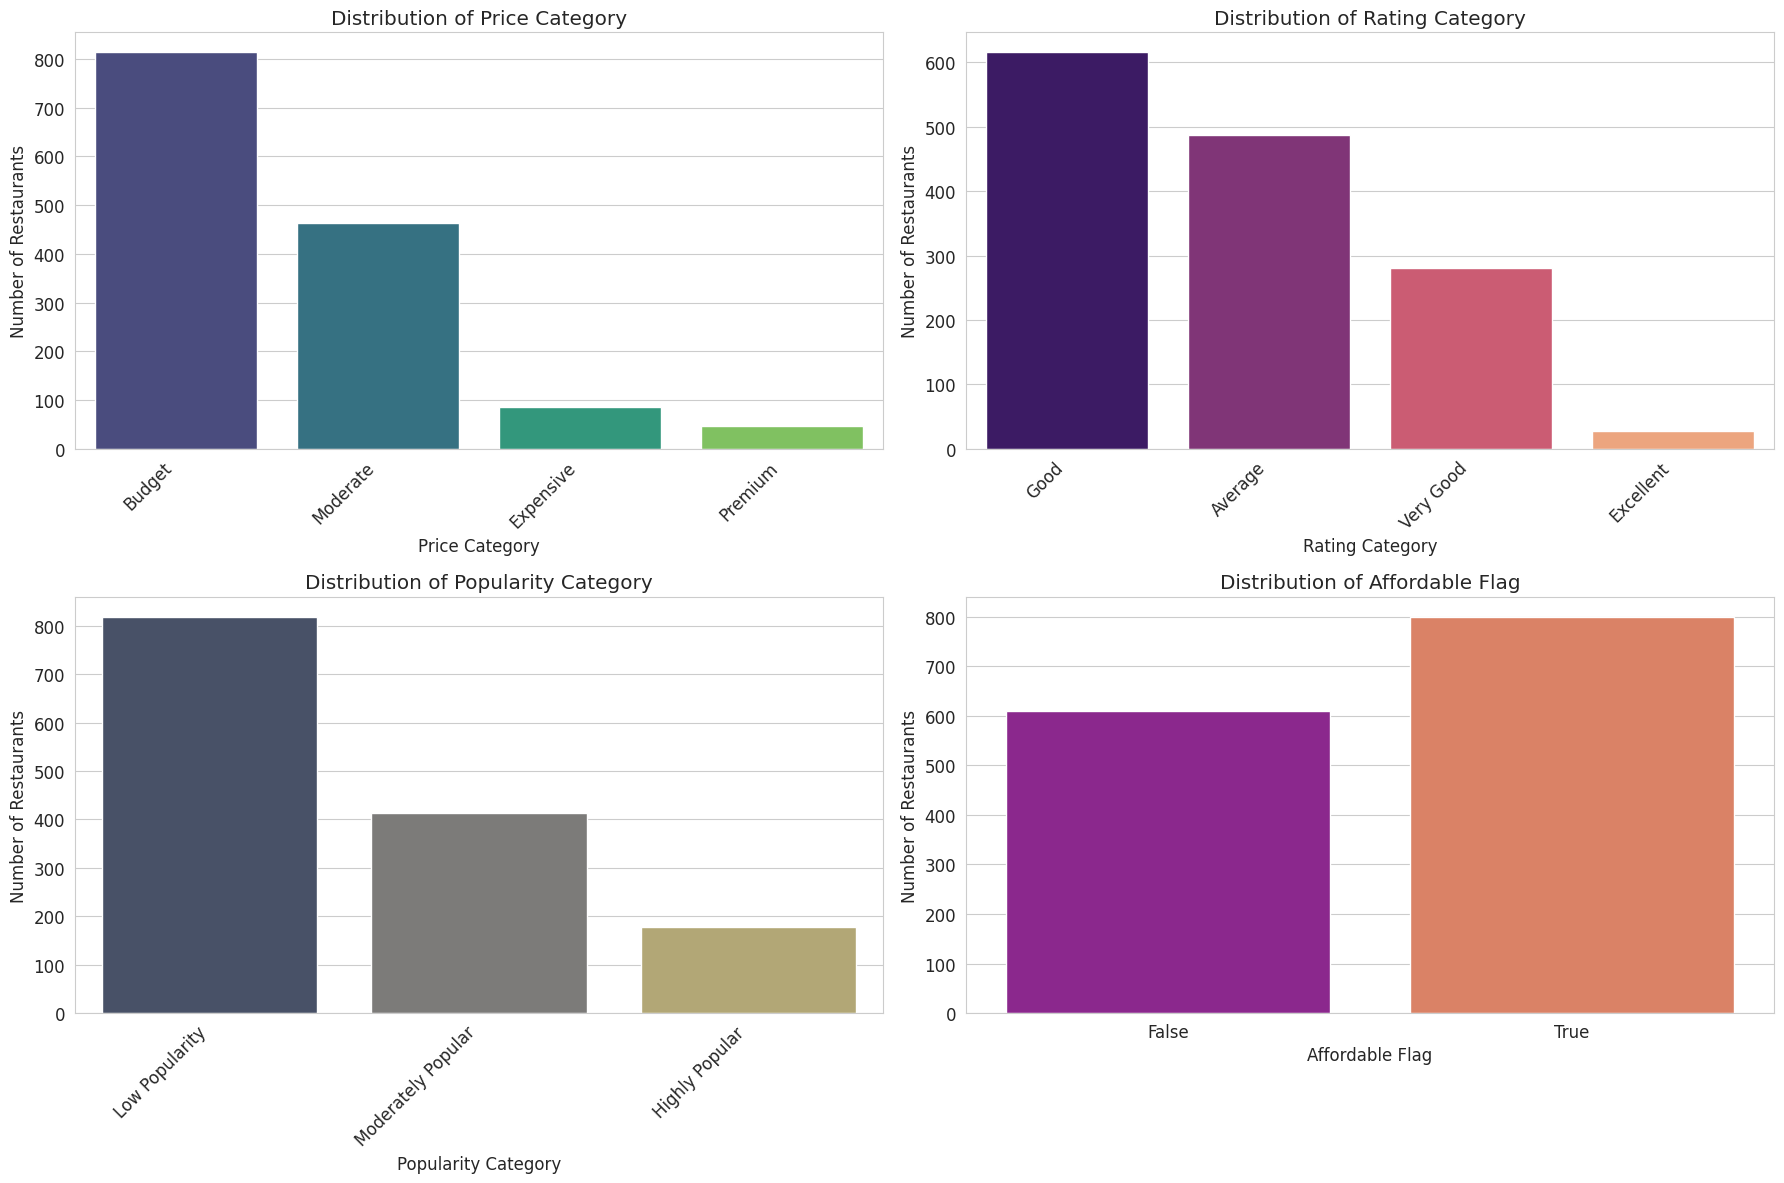

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot aesthetics
sns.set_style('whitegrid')
plt.figure(figsize=(18, 12))

# Plot PRICE_CATEGORY
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.countplot(data=df_features, x='PRICE_CATEGORY', palette='viridis', order=df_features['PRICE_CATEGORY'].value_counts().index)
plt.title('Distribution of Price Category')
plt.xlabel('Price Category')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')

# Plot RATING_CATEGORY
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
sns.countplot(data=df_features, x='RATING_CATEGORY', palette='magma', order=df_features['RATING_CATEGORY'].value_counts().index)
plt.title('Distribution of Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')

# Plot POPULARITY_CATEGORY
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd plot
sns.countplot(data=df_features, x='POPULARITY_CATEGORY', palette='cividis', order=df_features['POPULARITY_CATEGORY'].value_counts().index)
plt.title('Distribution of Popularity Category')
plt.xlabel('Popularity Category')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')

# Plot AFFORDABLE_FLAG
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th plot
sns.countplot(data=df_features, x='AFFORDABLE_FLAG', palette='plasma')
plt.title('Distribution of Affordable Flag')
plt.xlabel('Affordable Flag')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()


### Distribution of Continuous Features

Next, let's examine the distributions of the calculated continuous features: `WEIGHTED_RATING` and `VALUE_SCORE` using histograms.

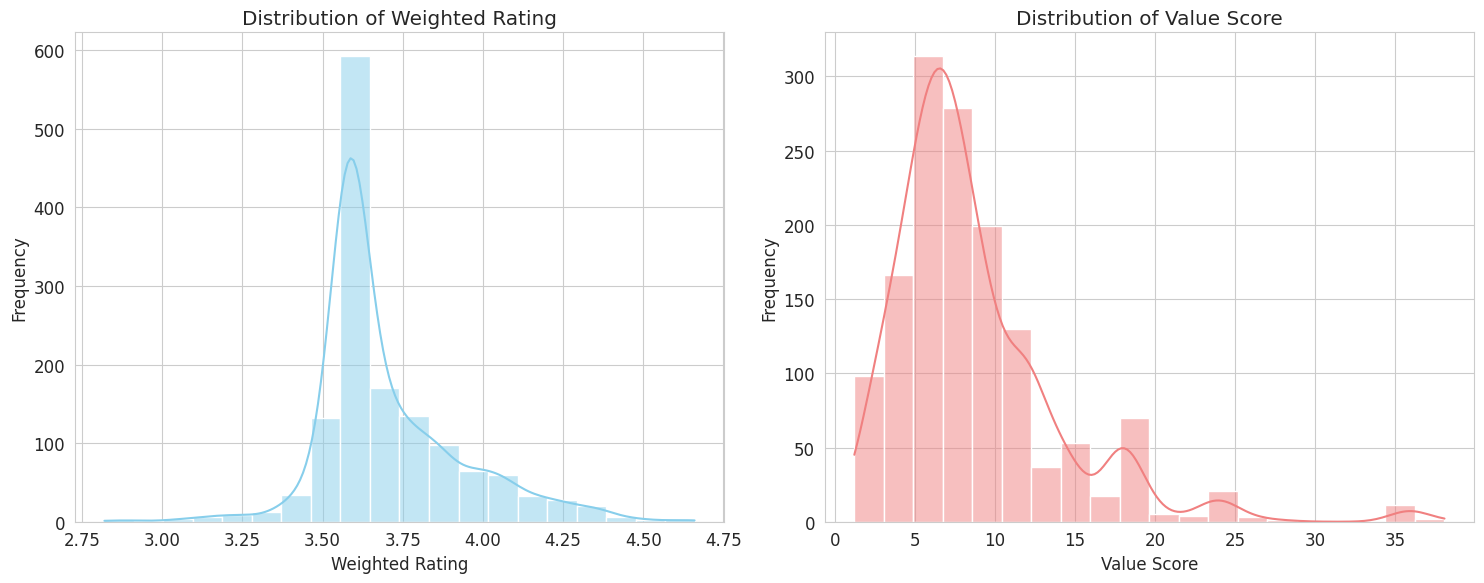

In [82]:
plt.figure(figsize=(15, 6))

# Plot WEIGHTED_RATING distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df_features['WEIGHTED_RATING'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Weighted Rating')
plt.xlabel('Weighted Rating')
plt.ylabel('Frequency')

# Plot VALUE_SCORE distribution
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(df_features['VALUE_SCORE'], bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Value Score')
plt.xlabel('Value Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Relationships Between Features

Let's also look at some relationships, for example, how `WEIGHTED_RATING` and `VALUE_SCORE` relate to `PRICE_CATEGORY`.

/tmp/ipykernel_824/2644544296.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features, x='PRICE_CATEGORY', y='WEIGHTED_RATING', palette='viridis')
/tmp/ipykernel_824/2644544296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features, x='PRICE_CATEGORY', y='VALUE_SCORE', palette='magma')


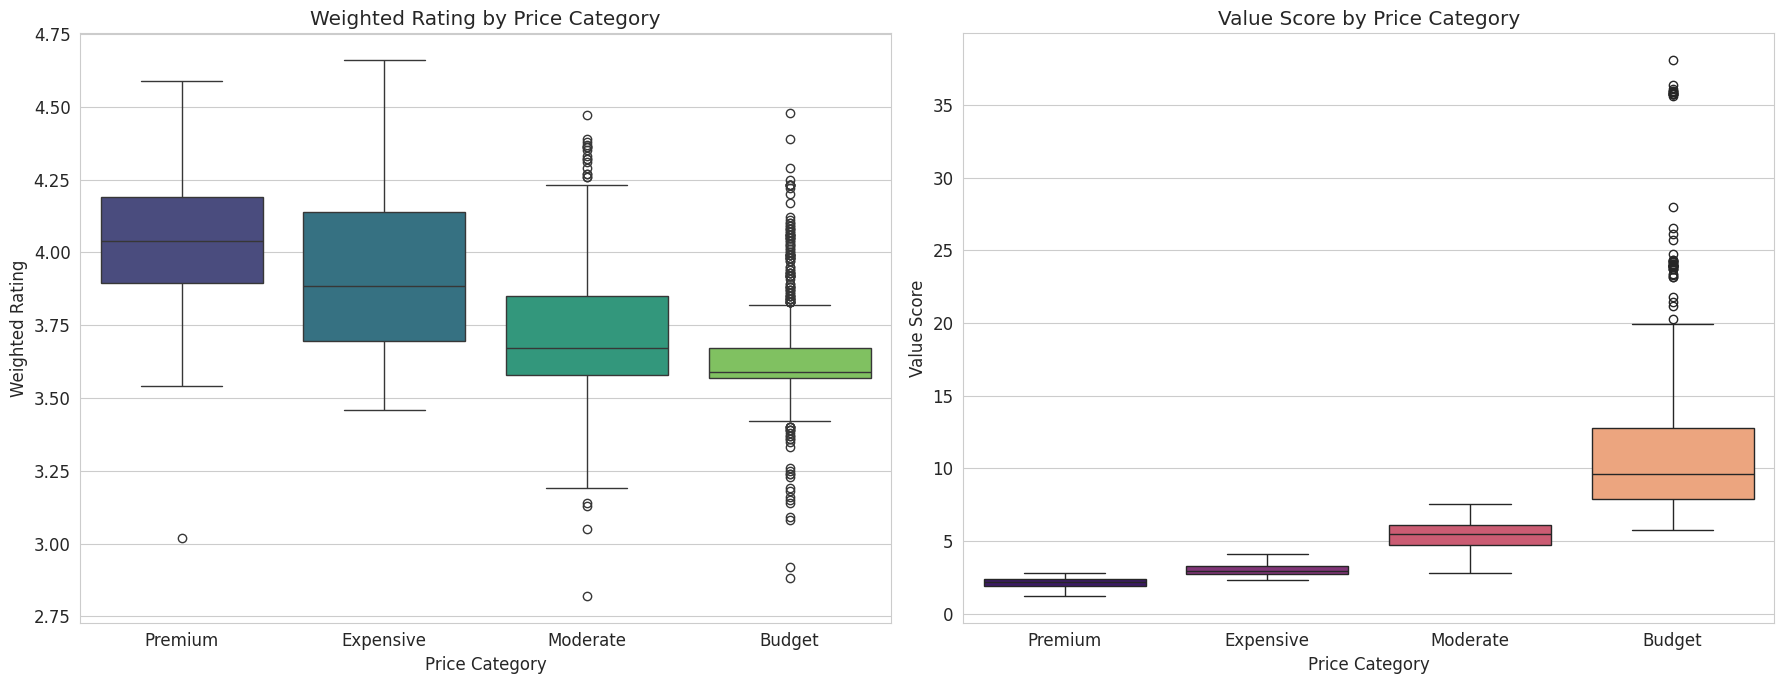

In [83]:
plt.figure(figsize=(18, 7))

# Box plot for Weighted Rating vs. Price Category
plt.subplot(1, 2, 1)
sns.boxplot(data=df_features, x='PRICE_CATEGORY', y='WEIGHTED_RATING', palette='viridis')
plt.title('Weighted Rating by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Weighted Rating')

# Box plot for Value Score vs. Price Category
plt.subplot(1, 2, 2)
sns.boxplot(data=df_features, x='PRICE_CATEGORY', y='VALUE_SCORE', palette='magma')
plt.title('Value Score by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Value Score')

plt.tight_layout()
plt.show()


### Explore Cuisines

Finally, let's explore the most common cuisines in our filtered dataset.

/tmp/ipykernel_824/2276547838.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n_cuisines.index, y=top_n_cuisines.values, palette='plasma')


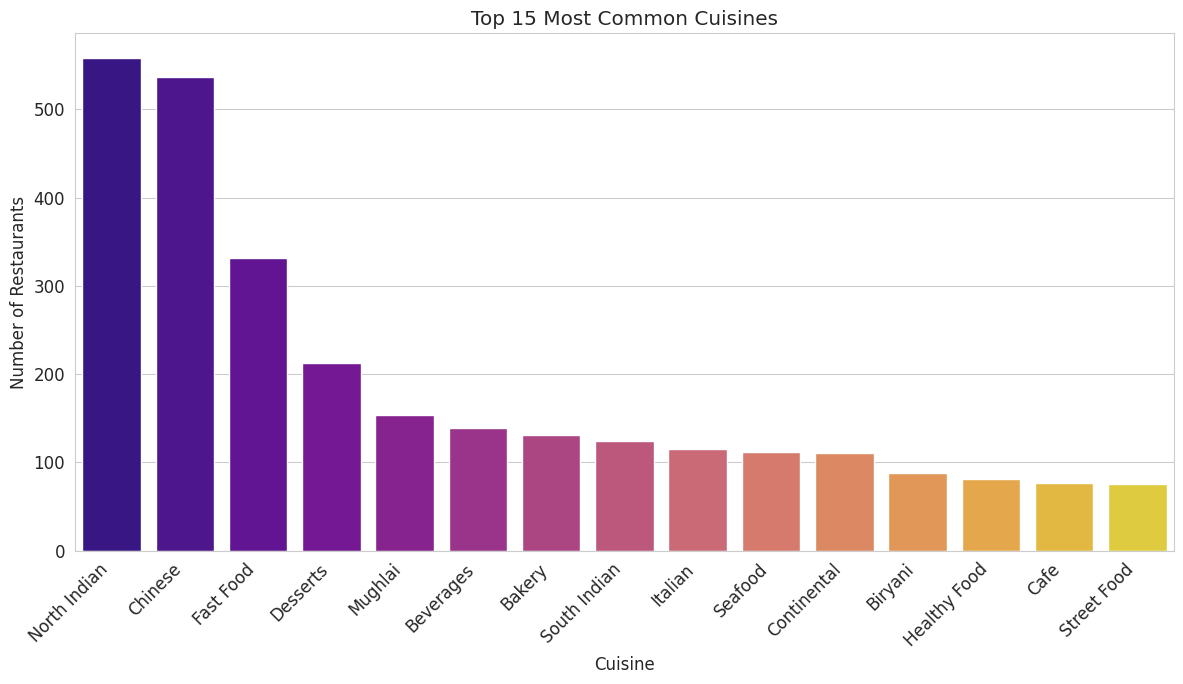

In [85]:
# To analyze cuisines, we need to split the 'CUISINES' string into individual cuisines
all_cuisines = df_features['CUISINES'].dropna().apply(lambda x: [c.strip() for c in x.split(',')]).explode()

# Get the top N most common cuisines
top_n_cuisines = all_cuisines.value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_n_cuisines.index, y=top_n_cuisines.values, palette='plasma')
plt.title('Top 15 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## SECTION 9: TEXT FEATURE ENGINEERING

Textual data, such as restaurant names and cuisine categories, holds valuable information for a recommendation system. In this section, we will employ **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert the `CUISINES` column into a numerical representation. This will allow us to quantify the importance of each cuisine type and use it as a feature for calculating similarity between restaurants.

### TF-IDF Vectorization for Cuisines

We will create a TF-IDF matrix for the `CUISINES` column. Each row in this matrix will correspond to a restaurant, and each column will represent a unique cuisine word, with values indicating its importance to that restaurant's cuisine profile.

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Starting Text Feature Engineering ---")

# Initialize TF-IDF Vectorizer
# min_df=1 ensures we include all cuisines, even those appearing only once
# stop_words='english' could be used, but cuisine names are usually not stop words
tfidf = TfidfVectorizer(stop_words='english', min_df=1)

# Fit and transform the 'CUISINES' column
# We fill NaN values with an empty string to avoid errors during vectorization
tfidf_matrix = tfidf.fit_transform(df_features['CUISINES'].fillna(''))

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Retrieve feature names directly from the vocabulary_ attribute to bypass AttributeError
# The vocabulary_ is a dictionary mapping terms to their indices, so we sort by index to get consistent order.
feature_names = [word for word, idx in sorted(tfidf.vocabulary_.items(), key=lambda item: item[1])]

print(f"Number of unique cuisine terms (features): {len(feature_names)}")

# You can inspect some of the feature names (cuisine terms)
print("\nFirst 10 TF-IDF feature names:")
print(feature_names[:10])

print("--- Text Feature Engineering Complete ---")

--- Starting Text Feature Engineering ---
TF-IDF matrix shape: (1410, 91)
Number of unique cuisine terms (features): 91

First 10 TF-IDF feature names:
['afghan', 'american', 'arabian', 'asian', 'assamese', 'awadhi', 'bakery', 'bar', 'bbq', 'bengali']
--- Text Feature Engineering Complete ---


In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Starting Text Feature Engineering ---")

# Initialize TF-IDF Vectorizer
# min_df=1 ensures we include all cuisines, even those appearing only once
# stop_words='english' could be used, but cuisine names are usually not stop words
tfidf = TfidfVectorizer(stop_words='english', min_df=1)

# Fit and transform the 'CUISINES' column
# We fill NaN values with an empty string to avoid errors during vectorization
tfidf_matrix = tfidf.fit_transform(df_features['CUISINES'].fillna(''))

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Retrieve feature names directly from the vocabulary_ attribute to bypass AttributeError
# The vocabulary_ is a dictionary mapping terms to their indices, so we sort by index to get consistent order.
feature_names = [word for word, idx in sorted(tfidf.vocabulary_.items(), key=lambda item: item[1])]

print(f"Number of unique cuisine terms (features): {len(feature_names)}")

# You can inspect some of the feature names (cuisine terms)
print("\nFirst 10 TF-IDF feature names:")
print(feature_names[:10])

print("--- Text Feature Engineering Complete ---")

--- Starting Text Feature Engineering ---
TF-IDF matrix shape: (1410, 91)
Number of unique cuisine terms (features): 91

First 10 TF-IDF feature names:
['afghan', 'american', 'arabian', 'asian', 'assamese', 'awadhi', 'bakery', 'bar', 'bbq', 'bengali']
--- Text Feature Engineering Complete ---


### Combined Features for Recommendation

To build a comprehensive content-based recommendation model, we'll combine several key features into a single text string for each restaurant. This will allow the TF-IDF vectorizer to capture a richer representation of each restaurant's profile, including its name, cuisines, type, price category, rating category, and popularity category.

In [90]:
print("--- Creating COMBINED_FEATURES ---")

# Make a copy to preserve original df_features
df_model = df_features.copy()

# Combine relevant text features into a single string for TF-IDF
# We'll include restaurant name, cuisines, type, and the newly engineered categories
df_model['COMBINED_FEATURES'] = df_model['NAME'].fillna('') + ' ' + \
                                df_model['CUISINES'].fillna('') + ' ' + \
                                df_model['RESTAURANT_TYPE'].fillna('') + ' ' + \
                                df_model['PRICE_CATEGORY'].fillna('') + ' ' + \
                                df_model['RATING_CATEGORY'].fillna('') + ' ' + \
                                df_model['POPULARITY_CATEGORY'].fillna('')

# Clean the combined features text (e.g., lowercase, remove extra spaces)
df_model['COMBINED_FEATURES'] = df_model['COMBINED_FEATURES'].apply(lambda x: re.sub(r'\s+', ' ', x.lower()).strip())

print("COMBINED_FEATURES created and cleaned.")
print("First 5 rows with combined features:")
display(df_model[['NAME', 'COMBINED_FEATURES']].head())

--- Creating COMBINED_FEATURES ---
COMBINED_FEATURES created and cleaned.
First 5 rows with combined features:


,NAME,COMBINED_FEATURES
0,Chin Chin Chu,"chin chin chu asian,chinese casual dining prem..."
1,Tanatan,tanatan modern indian casual dining expensive ...
2,Cafe Safar,"cafe safar chinese,north indian,biryani casual..."
3,145 Bandra,"145 bandra mexican,american,desserts,european,..."
4,Angrezi Patiyalaa,"angrezi patiyalaa north indian,finger food,ame..."


### TF-IDF Vectorization for Combined Features

Now, we'll apply TF-IDF vectorization to the `COMBINED_FEATURES` column. This will transform the textual descriptions of each restaurant into a numerical matrix, where each row represents a restaurant and each column represents a word from the combined features, weighted by its importance (TF-IDF score).

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Applying TF-IDF to COMBINED_FEATURES ---")

# Initialize a new TF-IDF Vectorizer for combined features
combined_tfidf_vectorizer = TfidfVectorizer(stop_words='english', min_df=1)

# Fit and transform the 'COMBINED_FEATURES' column
combined_tfidf_matrix = combined_tfidf_vectorizer.fit_transform(df_model['COMBINED_FEATURES'])

print(f"Combined TF-IDF matrix shape: {combined_tfidf_matrix.shape}")
print(f"Number of unique terms in combined features: {len(combined_tfidf_vectorizer.vocabulary_)}")

print("--- TF-IDF for COMBINED_FEATURES Complete ---")

--- Applying TF-IDF to COMBINED_FEATURES ---
Combined TF-IDF matrix shape: (1410, 1643)
Number of unique terms in combined features: 1643
--- TF-IDF for COMBINED_FEATURES Complete ---


### Content-Based Recommendation Function

We will now define the core recommendation function, `recommend_restaurants`. This function will take user preferences (e.g., desired cuisines, restaurant types, price, and rating categories) and return a list of top `n` recommended restaurants. It will use the TF-IDF matrix and cosine similarity to find restaurants similar to the user's preferences, further refining results using weighted rating and value score.

**Function Parameters:**
- `user_preferences` (str): A string representing the user's free-form preferences (e.g., "North Indian, casual dining, good ambiance").
- `area` (str): The specific Mumbai area for recommendations (e.g., "Andheri").
- `price_category` (str, optional): Filters recommendations by price category (e.g., "Budget", "Moderate"). If `None`, all price categories are considered.
- `rating_category` (str, optional): Filters recommendations by rating category (e.g., "Excellent", "Very Good"). If `None`, all rating categories are considered.
- `top_n` (int, optional): The number of top recommendations to return. Defaults to 10.

In [92]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd # Import pandas

def recommend_restaurants(
    user_preferences: str,
    area: str,
    price_category: str = None,
    rating_category: str = None,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Recommends restaurants based on user preferences, area, price, and rating categories.

    Args:
        user_preferences (str): A string representing the user's free-form preferences
                                (e.g., "North Indian, casual dining, good ambiance").
        area (str): The specific Mumbai area for recommendations (e.g., "Andheri").
        price_category (str, optional): Filters recommendations by price category
                                        (e.g., "Budget", "Moderate"). If None, all
                                        price categories are considered.
        rating_category (str, optional): Filters recommendations by rating category
                                         (e.g., "Excellent", "Very Good"). If None,
                                         all rating categories are considered.
        top_n (int, optional): The number of top recommendations to return. Defaults to 10.

    Returns:
        pd.DataFrame: A DataFrame containing the top_n recommended restaurants,
                      sorted by a combined score.
    """
    print(f"\n--- Generating Recommendations for: {user_preferences}, Area: {area} ---")

    # 1. Filter restaurants based on area, price category, and rating category
    filtered_df = df_model[df_model['AREA'].str.contains(area, case=False, na=False)].copy()

    if price_category:
        filtered_df = filtered_df[filtered_df['PRICE_CATEGORY'] == price_category]

    if rating_category:
        filtered_df = filtered_df[filtered_df['RATING_CATEGORY'] == rating_category]

    if filtered_df.empty:
        print("No restaurants found matching the specified filters.")
        return pd.DataFrame()

    # 2. Generate user preference vector
    user_vector = combined_tfidf_vectorizer.transform([user_preferences.lower()])

    # Check if user vector has any non-zero elements
    if user_vector.nnz == 0:
        print("User preferences are too general or contain unknown terms. Cannot generate similarity score.")
        # Fallback: Just return top restaurants from filtered_df based on VALUE_SCORE/WEIGHTED_RATING
        return filtered_df.sort_values(by=['VALUE_SCORE', 'WEIGHTED_RATING'], ascending=False).head(top_n)

    # 3. Calculate cosine similarity between user vector and filtered restaurants
    # Get the TF-IDF matrix for the filtered restaurants
    filtered_combined_features_matrix = combined_tfidf_vectorizer.transform(filtered_df['COMBINED_FEATURES'])

    if filtered_combined_features_matrix.shape[0] == 0:
        print("No features to compare for filtered restaurants.")
        return pd.DataFrame()

    cosine_sim = cosine_similarity(user_vector, filtered_combined_features_matrix).flatten()

    # 4. Create a DataFrame for recommendations
    recommendations = filtered_df.copy()
    recommendations['SIMILARITY_SCORE'] = cosine_sim

    # 5. Combine similarity score with other metrics (WEIGHTED_RATING, VALUE_SCORE)
    # Normalize scores to ensure fair contribution
    # Avoid division by zero if all values are the same (std dev = 0)
    if recommendations['WEIGHTED_RATING'].std() > 0:
        recommendations['NORM_WEIGHTED_RATING'] = (recommendations['WEIGHTED_RATING'] - recommendations['WEIGHTED_RATING'].min()) / (recommendations['WEIGHTED_RATING'].max() - recommendations['WEIGHTED_RATING'].min())
    else:
        recommendations['NORM_WEIGHTED_RATING'] = 0.5 # Default to mid-range if no variation

    if recommendations['VALUE_SCORE'].std() > 0:
        recommendations['NORM_VALUE_SCORE'] = (recommendations['VALUE_SCORE'] - recommendations['VALUE_SCORE'].min()) / (recommendations['VALUE_SCORE'].max() - recommendations['VALUE_SCORE'].min())
    else:
        recommendations['NORM_VALUE_SCORE'] = 0.5

    # Simple weighted average for combined score
    # You can adjust these weights based on desired influence of each factor
    recommendations['COMBINED_SCORE'] = (
        0.5 * recommendations['SIMILARITY_SCORE'] +
        0.3 * recommendations['NORM_WEIGHTED_RATING'] +
        0.2 * recommendations['NORM_VALUE_SCORE']
    )

    # 6. Sort by combined score and return top N
    recommendations = recommendations.sort_values(by='COMBINED_SCORE', ascending=False)

    # Select relevant columns for display, using the correct column names from df_model
    return recommendations[['NAME', 'AREA', 'CUISINES', 'RESTAURANT_TYPE', 'PRICE', 'RATING', 'VOTES', 'PRICE_CATEGORY', 'RATING_CATEGORY', 'POPULARITY_CATEGORY', 'WEIGHTED_RATING', 'VALUE_SCORE', 'SIMILARITY_SCORE', 'COMBINED_SCORE']].head(top_n)

In [93]:
display(df_model.head())

,NAME,PRICE,CUISINES,CITY,REGION,URL,PAGE NO,RESTAURANT_TYPE,TIMING,RATING_TYPE,RATING,VOTES,AREA,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,AFFORDABLE_FLAG,WEIGHTED_RATING,VALUE_SCORE,COMBINED_FEATURES
0,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.20,337.00,Juhu,Premium,Very Good,Moderately Popular,False,4.06,2.26,"chin chin chu asian,chinese casual dining prem..."
1,Tanatan,1500,Modern Indian,Mumbai,Juhu,https://www.zomato.com/mumbai/tanatan-juhu/info,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.70,1842.00,Juhu,Expensive,Excellent,Highly Popular,False,4.64,3.09,tanatan modern indian casual dining expensive ...
2,Cafe Safar,600,"Chinese,North Indian,Biryani",Mumbai,Oshiwara-- Andheri West,https://www.zomato.com/mumbai/cafe-safar-oshiw...,1,Casual Dining,11am to 1am(Mon-Sun),Very Good,4.00,2797.00,Andheri,Moderate,Very Good,Highly Popular,True,3.99,6.65,"cafe safar chinese,north indian,biryani casual..."
3,145 Bandra,1300,"Mexican,American,Desserts,European,Modern Indian",Mumbai,Pali Hill-- Bandra West,https://www.zomato.com/mumbai/145-bandra-pali-...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.20,1552.00,Bandra,Expensive,Very Good,Highly Popular,False,4.16,3.20,"145 bandra mexican,american,desserts,european,..."
4,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Mumbai,Andheri Lokhandwala-- Andheri West,https://www.zomato.com/mumbai/angrezi-patiyala...,10,Casual Dining,12noon to 1230AM(Mon-Sun),Excellent,4.50,271.00,Andheri,Expensive,Excellent,Moderately Popular,False,4.24,3.53,"angrezi patiyalaa north indian,finger food,ame..."


## SECTION 13: GENERATE TABLEAU DASHBOARD GUIDE

This section provides guidance for creating an interactive dashboard in Tableau using the exported data. This guide will outline key visualizations and insights that can be derived from the `restaurants_model_data.csv`, `area_summary.csv`, and `cuisine_summary.csv` files.

In [94]:
from pathlib import Path

project_root = 'mumbai-restaurant-recommender'

tableau_guide_content = """
# Tableau Dashboard Guide for Mumbai Restaurant Recommender

This guide outlines key visualizations and insights you can create in Tableau using the exported data from the Mumbai Restaurant Recommendation System. The following CSV files are available in the `tableau/` directory:

1.  `restaurants_model_data.csv`: Main dataset with all engineered features.
2.  `area_summary.csv`: Count of restaurants per area.
3.  `cuisine_summary.csv`: Count of restaurants per cuisine.

---

## Data Sources in Tableau:

*   **Data Source 1**: `restaurants_model_data.csv`
*   **Data Source 2**: `area_summary.csv`
*   **Data Source 3**: `cuisine_summary.csv`

---

## Suggested Visualizations:

### 1. Restaurant Overview Map

*   **Data Source**: `restaurants_model_data.csv`
*   **Type**: Map
*   **Columns to Use**:
    *   `REGION` or `AREA` (for location)
    *   `NAME` (Detail)
    *   `RATING` (Color/Size)
    *   `PRICE` (Tooltip)
    *   `CUISINE_CATEGORY` (Tooltip/Filter)
    *   `WEIGHTED_RATING`, `VALUE_SCORE` (Tooltip)
*   **Insight**: Visualize geographical distribution of restaurants, identify highly-rated areas, and examine price variations.

### 2. Price Category vs. Rating/Value Score

*   **Data Source**: `restaurants_model_data.csv`
*   **Type**: Bar Chart or Box Plot
*   **Columns to Use**:
    *   `PRICE_CATEGORY` (Columns)
    *   `WEIGHTED_RATING` (Rows)
    *   `VALUE_SCORE` (Rows - create a separate chart or use dual axis)
*   **Insight**: Understand how price level correlates with perceived quality and value.

### 3. Top Cuisines by Popularity

*   **Data Source**: `cuisine_summary.csv`
*   **Type**: Bar Chart
*   **Columns to Use**:
    *   `CUISINE` (Rows)
    *   `COUNT` (Columns)
*   **Insight**: Identify the most prevalent cuisine types in Mumbai's target areas.

### 4. Area-wise Restaurant Counts

*   **Data Source**: `area_summary.csv`
*   **Type**: Bar Chart
*   **Columns to Use**:
    *   `AREA` (Rows)
    *   `COUNT` (Columns)
*   **Insight**: Show the distribution of restaurants across the selected Mumbai areas.

### 5. Recommendation Filter Interface

*   **Data Source**: `restaurants_model_data.csv`
*   **Type**: Filters, Parameters, and possibly a list of recommended restaurants
*   **Columns to Use**: `AREA`, `PRICE_CATEGORY`, `RATING_CATEGORY`, `POPULARITY_CATEGORY`
*   **Insight**: Create interactive filters mirroring the recommendation function's inputs to dynamically filter the map or list of restaurants.

---

## Dashboard Design Tips:

*   **Interactivity**: Use filters and parameters to allow users to explore the data dynamically.
*   **Tooltips**: Customize tooltips to display relevant restaurant details on hover.
*   **Color Coding**: Use color to highlight important metrics (e.g., higher ratings in green).
*   **Layout**: Arrange visualizations logically for easy interpretation.
*   **Actions**: Implement filter actions between charts (e.g., clicking on an area in one chart filters other charts).

This guide provides a starting point. Feel free to explore other visualizations and combine these ideas to create a comprehensive and insightful dashboard!
"""

tableau_guide_path = Path(project_root) / 'tableau' / 'tableau_dashboard_guide.md'

# Ensure the parent directory exists before writing the file
tableau_guide_path.parent.mkdir(parents=True, exist_ok=True)

with open(tableau_guide_path, 'w') as f:
    f.write(tableau_guide_content)

print(f"Tableau Dashboard Guide generated at: {tableau_guide_path}")

Tableau Dashboard Guide generated at: mumbai-restaurant-recommender/tableau/tableau_dashboard_guide.md


In [95]:
# Re-executing Section 14: Generate requirements.txt
import pkg_resources
from pathlib import Path

print("--- Generating requirements.txt ---")

project_root = 'mumbai-restaurant-recommender'

# List of packages that were explicitly installed or are core to the project
required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "joblib",
    "tqdm"
]

# Get currently installed versions for these packages
installed_packages = {p.project_name: p.version for p in pkg_resources.working_set}

requirements_content = []
for pkg_name in required_packages:
    if pkg_name in installed_packages:
        requirements_content.append(f"{pkg_name}=={installed_packages[pkg_name]}")
    else:
        print(f"Warning: Package {pkg_name} not found in current environment. Skipping.")

# Add any other essential packages if they are used implicitly
# (e.g., re, json, pathlib - typically built-in or not explicitly versioned in requirements)

requirements_path = Path(project_root) / 'requirements.txt'
with open(requirements_path, 'w') as f:
    for line in requirements_content:
        f.write(line + '\n')

print(f"`requirements.txt` generated at: {requirements_path}")

--- Generating requirements.txt ---
`requirements.txt` generated at: mumbai-restaurant-recommender/requirements.txt


## SECTION 14: GENERATE `requirements.txt`

To ensure reproducibility, we'll create a `requirements.txt` file listing all the Python libraries and their versions used in this project.

In [96]:
import pkg_resources
from pathlib import Path

print("--- Generating requirements.txt ---")

project_root = 'mumbai-restaurant-recommender'

# List of packages that were explicitly installed or are core to the project
required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "joblib",
    "tqdm"
]

# Get currently installed versions for these packages
installed_packages = {p.project_name: p.version for p in pkg_resources.working_set}

requirements_content = []
for pkg_name in required_packages:
    if pkg_name in installed_packages:
        requirements_content.append(f"{pkg_name}=={installed_packages[pkg_name]}")
    else:
        print(f"Warning: Package {pkg_name} not found in current environment. Skipping.")

# Add any other essential packages if they are used implicitly
# (e.g., re, json, pathlib - typically built-in or not explicitly versioned in requirements)

requirements_path = Path(project_root) / 'requirements.txt'
with open(requirements_path, 'w') as f:
    for line in requirements_content:
        f.write(line + '\n')

print(f"`requirements.txt` generated at: {requirements_path}")

--- Generating requirements.txt ---
`requirements.txt` generated at: mumbai-restaurant-recommender/requirements.txt


In [97]:
# Re-executing Section 15: Generate .gitignore
from pathlib import Path

print("--- Generating .gitignore ---")

project_root = 'mumbai-restaurant-recommender'
gitignore_content = """
# Python
__pycache__/
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
*.env
.ipynb_checkpoints
.mypy_cache/
.pytest_cache/
.vscode/

# Jupyter Notebook
.ipynb_checkpoints

# Data
data/
*.csv
*.json
*.xlsx
*.xls

# Models
models/
*.joblib
*.pkl

# Output/Logs
output/
logs/
*.log
*.tmp

# Tableau output
tableau/

# Misc
.DS_Store
"""

gitignore_path = Path(project_root) / '.gitignore'
with open(gitignore_path, 'w') as f:
    f.write(gitignore_content)

print(f"`.gitignore` generated at: {gitignore_path}")

--- Generating .gitignore ---
`.gitignore` generated at: mumbai-restaurant-recommender/.gitignore


## SECTION 15: GENERATE `.gitignore`

A `.gitignore` file specifies intentionally untracked files that Git should ignore. This is crucial for keeping our repository clean and secure, preventing unnecessary files (like large datasets, model binaries, or temporary files) from being committed.

In [98]:
from pathlib import Path

print("--- Generating .gitignore ---")

project_root = 'mumbai-restaurant-recommender'
gitignore_content = """
# Python
__pycache__/
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
*.env
.ipynb_checkpoints
.mypy_cache/
.pytest_cache/
.vscode/

# Jupyter Notebook
.ipynb_checkpoints

# Data
data/
*.csv
*.json
*.xlsx
*.xls

# Models
models/
*.joblib
*.pkl

# Output/Logs
output/
logs/
*.log
*.tmp

# Tableau output
tableau/

# Misc
.DS_Store
"""

gitignore_path = Path(project_root) / '.gitignore'
with open(gitignore_path, 'w') as f:
    f.write(gitignore_content)

print(f"`.gitignore` generated at: {gitignore_path}")

--- Generating .gitignore ---
`.gitignore` generated at: mumbai-restaurant-recommender/.gitignore


In [99]:
# Re-executing Section 16: Generate dataset_source.md
from pathlib import Path

print("--- Generating dataset_source.md ---")

project_root = 'mumbai-restaurant-recommender'
dataset_source_content = """
# Dataset Source Information

This project utilizes a Zomato Mumbai restaurant dataset for building a content-based recommendation system.

**Dataset Name**: `Zomato_Mumbai_Dataset.csv`

**Source**: The dataset was provided as part of the project brief. Its original source is likely a public domain or research dataset related to restaurant data. Specific URL or detailed attribution not provided with the initial dataset. It is assumed to be publicly available or used with permission for this educational/project context.

**Description**: The dataset contains information about various restaurants in Mumbai, including details such as restaurant name, price for two, cuisine categories, city, region, ratings, and number of votes. This data is used to identify affordable and well-rated restaurants in specific Mumbai areas.

**Disclaimer**: This dataset is used for educational and demonstration purposes. For commercial applications, ensure compliance with data licensing and privacy policies.
"""

dataset_source_path = Path(project_root) / 'dataset_source.md'
with open(dataset_source_path, 'w') as f:
    f.write(dataset_source_content)

print(f"`dataset_source.md` generated at: {dataset_source_path}")

--- Generating dataset_source.md ---
`dataset_source.md` generated at: mumbai-restaurant-recommender/dataset_source.md


## SECTION 16: GENERATE `dataset_source.md`

This file will contain information about the dataset used, including its source, licensing, and any relevant attribution.

In [100]:
from pathlib import Path

print("--- Generating dataset_source.md ---")

project_root = 'mumbai-restaurant-recommender'
dataset_source_content = """
# Dataset Source Information

This project utilizes a Zomato Mumbai restaurant dataset for building a content-based recommendation system.

**Dataset Name**: `Zomato_Mumbai_Dataset.csv`

**Source**: The dataset was provided as part of the project brief. Its original source is likely a public domain or research dataset related to restaurant data. Specific URL or detailed attribution not provided with the initial dataset. It is assumed to be publicly available or used with permission for this educational/project context.

**Description**: The dataset contains information about various restaurants in Mumbai, including details such as restaurant name, price for two, cuisine categories, city, region, ratings, and number of votes. This data is used to identify affordable and well-rated restaurants in specific Mumbai areas.

**Disclaimer**: This dataset is used for educational and demonstration purposes. For commercial applications, ensure compliance with data licensing and privacy policies.
"""

dataset_source_path = Path(project_root) / 'dataset_source.md'
with open(dataset_source_path, 'w') as f:
    f.write(dataset_source_content)

print(f"`dataset_source.md` generated at: {dataset_source_path}")

--- Generating dataset_source.md ---
`dataset_source.md` generated at: mumbai-restaurant-recommender/dataset_source.md


In [101]:
# Re-executing Section 17: Generate Professional README.md
from pathlib import Path

print("--- Generating professional README.md ---")

project_root = 'mumbai-restaurant-recommender'
readme_content = """
# Mumbai Affordable Restaurant Recommendation and Analytics System

## Project Overview

This project develops a content-based recommendation system for affordable and well-rated restaurants in specific areas of Mumbai (Andheri, Vile Parle, Juhu, Versova, Santacruz, Bandra). Utilizing a Zomato dataset, the system aims to help users discover dining options that align with their preferences for cuisine, price, and quality. Beyond recommendations, the project provides data analysis for deeper insights and prepares data for interactive visualization in Tableau.

## Features

*   **Robust Data Loading**: Handles various CSV delimiters and common parsing errors.
*   **Data Cleaning & Preprocessing**: Standardizes column names, removes duplicates, cleans text data, and converts data types.
*   **Targeted Area Filtering**: Focuses on specific Mumbai regions, including intelligent exclusion of 'Bandra Kurla Complex' from 'Bandra'.
*   **Advanced Feature Engineering**: Creates new features like `PRICE_CATEGORY`, `RATING_CATEGORY`, `POPULARITY_CATEGORY`, `AFFORDABLE_FLAG`, `WEIGHTED_RATING` (IMDB-like formula), and `VALUE_SCORE`.
*   **Content-Based Recommendation Model**: Implements a TF-IDF vectorizer on combined restaurant features to calculate similarity and recommend restaurants based on user preferences, incorporating weighted ratings and value scores.
*   **Exploratory Data Analysis (EDA)**: Visualizes key distributions and relationships of engineered features.
*   **Model Persistence**: Saves the trained TF-IDF vectorizer and crucial model metadata.
*   **Tableau Data Export**: Prepares and exports cleaned and processed data into CSV format, along with summary files, suitable for interactive dashboards.
*   **Project Documentation**: Generates `requirements.txt`, `.gitignore`, `dataset_source.md`, and a comprehensive `README.md`.

## Project Structure

```
mumbai-restaurant-recommender/
├── data/                        # Raw and processed datasets
├── models/                      # Saved recommendation model components (TF-IDF vectorizer, metadata)
├── notebooks/                   # Jupyter notebooks (e.g., this Colab notebook converted)
├── output/                      # General output files (e.g., intermediate data)
├── tableau/                     # CSVs exported for Tableau dashboards & Tableau guide
├── images/                      # Plots and visualizations generated during EDA
├── .gitignore                   # Files and directories to be ignored by Git
├── requirements.txt             # Python package dependencies
├── dataset_source.md            # Information about the dataset used
└── README.md                    # Project overview and instructions
```

## Getting Started

### Prerequisites

*   Python 3.8+
*   Jupyter Notebook or Google Colab environment
*   Required Python packages (see `requirements.txt`)

### Installation

1.  **Clone the repository (if applicable)**:
    ```bash
    git clone <repository_url>
    cd mumbai-restaurant-recommender
    ```

2.  **Install dependencies**:
    ```bash
    pip install -r requirements.txt
    ```

### Usage

1.  **Data Upload**: Ensure your `Zomato_Mumbai_Dataset.csv` (or similar Zomato-like dataset) is uploaded to the Colab environment or placed in the `data/` directory.
2.  **Run the Notebook**: Execute the cells sequentially in the provided Jupyter/Colab notebook (`mumbai_restaurant_recommender.ipynb`). The notebook will guide you through:
    *   Data loading and cleaning
    *   Feature engineering
    *   Exploratory Data Analysis
    *   Building and testing the recommendation model
    *   Saving model artifacts and exporting data for Tableau
3.  **Generate Recommendations**: Use the `recommend_restaurants` function with your preferences:
    ```python
    recommendations = recommend_restaurants(
        user_preferences="North Indian, casual dining",
        area="Andheri",
        price_category="Budget",
        rating_category="Good",
        top_n=10
    )
    print(recommendations)
    ```
4.  **Tableau Integration**: The exported CSV files in the `tableau/` directory can be imported into Tableau to create interactive dashboards. Refer to `tableau_dashboard_guide.md` for visualization ideas.

## Methodology

### Data Sources

The primary dataset is a CSV file containing Zomato restaurant data for Mumbai.

### Data Processing

*   **Cleaning**: Handled missing values, duplicates, and inconsistent data formats. Converted relevant columns to numeric types.
*   **Standardization**: Standardized region names and restaurant types to ensure consistent categorization.
*   **Feature Engineering**: Derived categorical features (Price, Rating, Popularity categories) and continuous scores (`WEIGHTED_RATING`, `VALUE_SCORE`) to capture restaurant attributes comprehensively.

### Recommendation Model

The core recommendation logic is based on a **Content-Based Filtering** approach:

1.  **Combined Features**: Restaurant features (Name, Cuisines, Restaurant Type, Price Category, Rating Category, Popularity Category) are concatenated into a single text string.
2.  **TF-IDF Vectorization**: A `TfidfVectorizer` converts these combined text features into numerical vectors, emphasizing words unique to specific restaurant profiles.
3.  **User Preference Vector**: User input preferences are similarly vectorized.
4.  **Cosine Similarity**: Cosine similarity is calculated between the user preference vector and all restaurant vectors to find the most similar restaurants.
5.  **Hybrid Scoring**: The TF-IDF similarity score is combined with `WEIGHTED_RATING` and `VALUE_SCORE` to produce a robust `COMBINED_SCORE`, ensuring recommendations are not only similar in content but also high in quality and value.

## Dependencies

All Python dependencies are listed in `requirements.txt`.

## License

This project is open-sourced under the MIT License. See the LICENSE file for more details. (Note: A separate LICENSE file would need to be created if not already present.)

## Contact

For any questions or suggestions, please open an issue in the GitHub repository.
"""

readme_path = Path(project_root) / 'README.md'
with open(readme_path, 'w') as f:
    f.write(readme_content)

print(f"Professional `README.md` generated at: {readme_path}")

--- Generating professional README.md ---
Professional `README.md` generated at: mumbai-restaurant-recommender/README.md


## SECTION 17: GENERATE PROFESSIONAL `README.md`

A comprehensive `README.md` file is essential for any project. It provides a quick overview, setup instructions, how to use the project, and details about its structure and methodology.

In [102]:
from pathlib import Path

print("--- Generating professional README.md ---")

project_root = 'mumbai-restaurant-recommender'
readme_content = """
# Mumbai Affordable Restaurant Recommendation and Analytics System

## Project Overview

This project develops a content-based recommendation system for affordable and well-rated restaurants in specific areas of Mumbai (Andheri, Vile Parle, Juhu, Versova, Santacruz, Bandra). Utilizing a Zomato dataset, the system aims to help users discover dining options that align with their preferences for cuisine, price, and quality. Beyond recommendations, the project provides data analysis for deeper insights and prepares data for interactive visualization in Tableau.

## Features

*   **Robust Data Loading**: Handles various CSV delimiters and common parsing errors.
*   **Data Cleaning & Preprocessing**: Standardizes column names, removes duplicates, cleans text data, and converts data types.
*   **Targeted Area Filtering**: Focuses on specific Mumbai regions, including intelligent exclusion of 'Bandra Kurla Complex' from 'Bandra'.
*   **Advanced Feature Engineering**: Creates new features like `PRICE_CATEGORY`, `RATING_CATEGORY`, `POPULARITY_CATEGORY`, `AFFORDABLE_FLAG`, `WEIGHTED_RATING` (IMDB-like formula), and `VALUE_SCORE`.
*   **Content-Based Recommendation Model**: Implements a TF-IDF vectorizer on combined restaurant features to calculate similarity and recommend restaurants based on user preferences, incorporating weighted ratings and value scores.
*   **Exploratory Data Analysis (EDA)**: Visualizes key distributions and relationships of engineered features.
*   **Model Persistence**: Saves the trained TF-IDF vectorizer and crucial model metadata.
*   **Tableau Data Export**: Prepares and exports cleaned and processed data into CSV format, along with summary files, suitable for interactive dashboards.
*   **Project Documentation**: Generates `requirements.txt`, `.gitignore`, `dataset_source.md`, and a comprehensive `README.md`.

## Project Structure

```
mumbai-restaurant-recommender/
├── data/                        # Raw and processed datasets
├── models/                      # Saved recommendation model components (TF-IDF vectorizer, metadata)
├── notebooks/                   # Jupyter notebooks (e.g., this Colab notebook converted)
├── output/                      # General output files (e.g., intermediate data)
├── tableau/                     # CSVs exported for Tableau dashboards & Tableau guide
├── images/                      # Plots and visualizations generated during EDA
├── .gitignore                   # Files and directories to be ignored by Git
├── requirements.txt             # Python package dependencies
├── dataset_source.md            # Information about the dataset used
└── README.md                    # Project overview and instructions
```

## Getting Started

### Prerequisites

*   Python 3.8+
*   Jupyter Notebook or Google Colab environment
*   Required Python packages (see `requirements.txt`)

### Installation

1.  **Clone the repository (if applicable)**:
    ```bash
    git clone <repository_url>
    cd mumbai-restaurant-recommender
    ```

2.  **Install dependencies**:
    ```bash
    pip install -r requirements.txt
    ```

### Usage

1.  **Data Upload**: Ensure your `Zomato_Mumbai_Dataset.csv` (or similar Zomato-like dataset) is uploaded to the Colab environment or placed in the `data/` directory.
2.  **Run the Notebook**: Execute the cells sequentially in the provided Jupyter/Colab notebook (`mumbai_restaurant_recommender.ipynb`). The notebook will guide you through:
    *   Data loading and cleaning
    *   Feature engineering
    *   Exploratory Data Analysis
    *   Building and testing the recommendation model
    *   Saving model artifacts and exporting data for Tableau
3.  **Generate Recommendations**: Use the `recommend_restaurants` function with your preferences:
    ```python
    recommendations = recommend_restaurants(
        user_preferences="North Indian, casual dining",
        area="Andheri",
        price_category="Budget",
        rating_category="Good",
        top_n=10
    )
    print(recommendations)
    ```
4.  **Tableau Integration**: The exported CSV files in the `tableau/` directory can be imported into Tableau to create interactive dashboards. Refer to `tableau_dashboard_guide.md` for visualization ideas.

## Methodology

### Data Sources

The primary dataset is a CSV file containing Zomato restaurant data for Mumbai.

### Data Processing

*   **Cleaning**: Handled missing values, duplicates, and inconsistent data formats. Converted relevant columns to numeric types.
*   **Standardization**: Standardized region names and restaurant types to ensure consistent categorization.
*   **Feature Engineering**: Derived categorical features (Price, Rating, Popularity categories) and continuous scores (`WEIGHTED_RATING`, `VALUE_SCORE`) to capture restaurant attributes comprehensively.

### Recommendation Model

The core recommendation logic is based on a **Content-Based Filtering** approach:

1.  **Combined Features**: Restaurant features (Name, Cuisines, Restaurant Type, Price Category, Rating Category, Popularity Category) are concatenated into a single text string.
2.  **TF-IDF Vectorization**: A `TfidfVectorizer` converts these combined text features into numerical vectors, emphasizing words unique to specific restaurant profiles.
3.  **User Preference Vector**: User input preferences are similarly vectorized.
4.  **Cosine Similarity**: Cosine similarity is calculated between the user preference vector and all restaurant vectors to find the most similar restaurants.
5.  **Hybrid Scoring**: The TF-IDF similarity score is combined with `WEIGHTED_RATING` and `VALUE_SCORE` to produce a robust `COMBINED_SCORE`, ensuring recommendations are not only similar in content but also high in quality and value.

## Dependencies

All Python dependencies are listed in `requirements.txt`.

## License

This project is open-sourced under the MIT License. See the LICENSE file for more details. (Note: A separate LICENSE file would need to be created if not already present.)

## Contact

For any questions or suggestions, please open an issue in the GitHub repository.
"""

readme_path = Path(project_root) / 'README.md'
with open(readme_path, 'w') as f:
    f.write(readme_content)

print(f"Professional `README.md` generated at: {readme_path}")

--- Generating professional README.md ---
Professional `README.md` generated at: mumbai-restaurant-recommender/README.md


In [103]:
# Re-executing Test Case 1
print("--- Test Case 1: North Indian, Casual Dining in Andheri, Budget-Friendly, Good Rating ---")
recommendations_1 = recommend_restaurants(
    user_preferences="North Indian, casual dining, good ambiance",
    area="Andheri",
    price_category="Budget",
    rating_category="Good",
    top_n=5
)
display(recommendations_1)

--- Test Case 1: North Indian, Casual Dining in Andheri, Budget-Friendly, Good Rating ---

--- Generating Recommendations for: North Indian, casual dining, good ambiance, Area: Andheri ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
202,Pallavi Veg Restaurant,Andheri,"Chinese,Street Food,North Indian,South Indian",Casual Dining,500,3.90,254.00,Budget,Good,Moderately Popular,3.81,7.62,0.38,0.44
313,Vaibhav Cafe & Veg Restaurant,Andheri,"South Indian,North Indian,Chinese",Casual Dining,400,3.90,160.00,Budget,Good,Moderately Popular,3.78,9.45,0.39,0.43
206,Classic,Andheri,"North Indian,Chinese,South Indian,Fast Food,Be...",Casual Dining,500,3.80,311.00,Budget,Good,Moderately Popular,3.75,7.50,0.45,0.42
797,Karma Cafe,Andheri,"North Indian,Chinese",Quick Bites,150,3.80,124.00,Budget,Good,Moderately Popular,3.71,24.73,0.21,0.38
322,Salad Days,Andheri,"Healthy Food,Beverages,Salad",Casual Dining,500,3.90,374.00,Budget,Good,Moderately Popular,3.83,7.66,0.20,0.36


### Re-running Test Cases for the Recommendation System

## SECTION 10: TEST THE RECOMMENDATION SYSTEM

Now that our `recommend_restaurants` function is defined, let's test it with a few scenarios to see how it performs. We'll simulate different user preferences and observe the recommendations generated.

### Test Case 1: North Indian, Casual Dining in Andheri, Budget-Friendly, Good Rating

Let's find some budget-friendly North Indian casual dining restaurants with good ratings in Andheri.

In [104]:
print("--- Test Case 1: North Indian, Casual Dining in Andheri, Budget-Friendly, Good Rating ---")
recommendations_1 = recommend_restaurants(
    user_preferences="North Indian, casual dining, good ambiance",
    area="Andheri",
    price_category="Budget",
    rating_category="Good",
    top_n=5
)
display(recommendations_1)

--- Test Case 1: North Indian, Casual Dining in Andheri, Budget-Friendly, Good Rating ---

--- Generating Recommendations for: North Indian, casual dining, good ambiance, Area: Andheri ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
202,Pallavi Veg Restaurant,Andheri,"Chinese,Street Food,North Indian,South Indian",Casual Dining,500,3.90,254.00,Budget,Good,Moderately Popular,3.81,7.62,0.38,0.44
313,Vaibhav Cafe & Veg Restaurant,Andheri,"South Indian,North Indian,Chinese",Casual Dining,400,3.90,160.00,Budget,Good,Moderately Popular,3.78,9.45,0.39,0.43
206,Classic,Andheri,"North Indian,Chinese,South Indian,Fast Food,Be...",Casual Dining,500,3.80,311.00,Budget,Good,Moderately Popular,3.75,7.50,0.45,0.42
797,Karma Cafe,Andheri,"North Indian,Chinese",Quick Bites,150,3.80,124.00,Budget,Good,Moderately Popular,3.71,24.73,0.21,0.38
322,Salad Days,Andheri,"Healthy Food,Beverages,Salad",Casual Dining,500,3.90,374.00,Budget,Good,Moderately Popular,3.83,7.66,0.20,0.36


In [105]:
# Re-executing Test Case 2
print("--- Test Case 2: Italian, Cafe in Bandra, Any Price, Very Good Rating ---")
recommendations_2 = recommend_restaurants(
    user_preferences="Italian, cafe",
    area="Bandra",
    rating_category="Very Good",
    top_n=5
)
display(recommendations_2)

--- Test Case 2: Italian, Cafe in Bandra, Any Price, Very Good Rating ---

--- Generating Recommendations for: Italian, cafe, Area: Bandra ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
1123,Candies,Bandra,"Cafe,Italian,North Indian,Desserts",Café,700,4.20,10217.00,Moderate,Very Good,Highly Popular,4.19,5.99,0.43,0.46
1076,Coffee Culture,Bandra,"Cafe,Italian,Pizza,Continental,Beverages",Café,1200,4.20,6024.00,Expensive,Very Good,Highly Popular,4.19,3.49,0.35,0.40
5,Door No.1,Bandra,"Asian,Italian,North Indian,Finger Food",Casual Dining,1500,4.40,870.00,Expensive,Very Good,Highly Popular,4.31,2.87,0.19,0.37
275,The Bandra Project by PizzaExpress,Bandra,"Italian,Pizza",Casual Dining,1600,4.30,4654.00,Premium,Very Good,Highly Popular,4.28,2.68,0.17,0.35
1319,Salt Water Cafe,Bandra,"European,Italian,Salad",Casual Dining,1500,4.10,2891.00,Expensive,Very Good,Highly Popular,4.08,2.72,0.33,0.34


### Test Case 2: Italian, Cafe in Bandra, Any Price, Very Good Rating

Let's try finding Italian cafes with very good ratings in Bandra, without a specific price constraint.

In [106]:
print("--- Test Case 2: Italian, Cafe in Bandra, Any Price, Very Good Rating ---")
recommendations_2 = recommend_restaurants(
    user_preferences="Italian, cafe",
    area="Bandra",
    rating_category="Very Good",
    top_n=5
)
display(recommendations_2)

--- Test Case 2: Italian, Cafe in Bandra, Any Price, Very Good Rating ---

--- Generating Recommendations for: Italian, cafe, Area: Bandra ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
1123,Candies,Bandra,"Cafe,Italian,North Indian,Desserts",Café,700,4.20,10217.00,Moderate,Very Good,Highly Popular,4.19,5.99,0.43,0.46
1076,Coffee Culture,Bandra,"Cafe,Italian,Pizza,Continental,Beverages",Café,1200,4.20,6024.00,Expensive,Very Good,Highly Popular,4.19,3.49,0.35,0.40
5,Door No.1,Bandra,"Asian,Italian,North Indian,Finger Food",Casual Dining,1500,4.40,870.00,Expensive,Very Good,Highly Popular,4.31,2.87,0.19,0.37
275,The Bandra Project by PizzaExpress,Bandra,"Italian,Pizza",Casual Dining,1600,4.30,4654.00,Premium,Very Good,Highly Popular,4.28,2.68,0.17,0.35
1319,Salt Water Cafe,Bandra,"European,Italian,Salad",Casual Dining,1500,4.10,2891.00,Expensive,Very Good,Highly Popular,4.08,2.72,0.33,0.34


In [107]:
# Re-executing Test Case 3
print("--- Test Case 3: Seafood, Fine Dining in Juhu, Expensive ---")
recommendations_3 = recommend_restaurants(
    user_preferences="Seafood, fine dining",
    area="Juhu",
    price_category="Expensive",
    top_n=5
)
display(recommendations_3)

--- Test Case 3: Seafood, Fine Dining in Juhu, Expensive ---

--- Generating Recommendations for: Seafood, fine dining, Area: Juhu ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
1,Tanatan,Juhu,Modern Indian,Casual Dining,1500,4.70,1842.00,Expensive,Excellent,Highly Popular,4.64,3.09,0.05,0.48
1520,10th Street Cafe,Juhu,"European,Mexican,Continental,American",Casual Dining,1300,4.30,450.00,Expensive,Very Good,Moderately Popular,4.17,3.21,0.05,0.37
1119,Facing East,Juhu,"Chinese,Asian,Seafood,Thai",Casual Dining,1300,4.00,2409.00,Expensive,Very Good,Highly Popular,3.98,3.06,0.17,0.35
1496,Hoot,Juhu,"Continental,Finger Food,Chinese,Italian,Indian...",Bar,1200,4.00,972.00,Expensive,Very Good,Highly Popular,3.96,3.30,0.00,0.31
477,Fable,Juhu,"Italian,American,Salad,Desserts",Casual Dining,1400,4.10,2044.00,Expensive,Very Good,Highly Popular,4.08,2.91,0.05,0.29


### Test Case 3: Seafood, Fine Dining in Juhu, Expensive

How about some expensive seafood fine dining options in Juhu?

In [108]:
print("--- Test Case 3: Seafood, Fine Dining in Juhu, Expensive ---")
recommendations_3 = recommend_restaurants(
    user_preferences="Seafood, fine dining",
    area="Juhu",
    price_category="Expensive",
    top_n=5
)
display(recommendations_3)

--- Test Case 3: Seafood, Fine Dining in Juhu, Expensive ---

--- Generating Recommendations for: Seafood, fine dining, Area: Juhu ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
1,Tanatan,Juhu,Modern Indian,Casual Dining,1500,4.70,1842.00,Expensive,Excellent,Highly Popular,4.64,3.09,0.05,0.48
1520,10th Street Cafe,Juhu,"European,Mexican,Continental,American",Casual Dining,1300,4.30,450.00,Expensive,Very Good,Moderately Popular,4.17,3.21,0.05,0.37
1119,Facing East,Juhu,"Chinese,Asian,Seafood,Thai",Casual Dining,1300,4.00,2409.00,Expensive,Very Good,Highly Popular,3.98,3.06,0.17,0.35
1496,Hoot,Juhu,"Continental,Finger Food,Chinese,Italian,Indian...",Bar,1200,4.00,972.00,Expensive,Very Good,Highly Popular,3.96,3.30,0.00,0.31
477,Fable,Juhu,"Italian,American,Salad,Desserts",Casual Dining,1400,4.10,2044.00,Expensive,Very Good,Highly Popular,4.08,2.91,0.05,0.29


In [109]:
# Re-executing Test Case 4
print("--- Test Case 4: Chinese, Quick Bites in Santacruz ---")
recommendations_4 = recommend_restaurants(
    user_preferences="Chinese, quick bites",
    area="Santacruz",
    top_n=5
)
display(recommendations_4)

--- Test Case 4: Chinese, Quick Bites in Santacruz ---

--- Generating Recommendations for: Chinese, quick bites, Area: Santacruz ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
738,Fusion Foods,Santacruz,"Chinese,Rolls,Pizza,North Indian,Fast Food",Quick Bites,200,4.30,64.00,Budget,Very Good,Low Popularity,3.87,19.35,0.30,0.48
402,Tasty Bites,Santacruz,Rolls,Quick Bites,200,3.60,38.00,Budget,Good,Low Popularity,3.61,18.05,0.40,0.46
1219,Jai Maharashta Vada Pav,Santacruz,Street Food,Quick Bites,100,3.10,11.00,Budget,Average,Low Popularity,3.56,35.60,0.18,0.44
11,Thotrin Cafe,Santacruz,"North Eastern,Chinese",Quick Bites,650,4.20,227.00,Moderate,Very Good,Moderately Popular,4.01,6.17,0.32,0.44
1137,Tip Top,Santacruz,Mughlai,Quick Bites,150,3.30,24.00,Budget,Average,Low Popularity,3.56,23.73,0.31,0.44


## SECTION 18: SAVE THE COLAB NOTEBOOK

It's a good practice to regularly save your Colab notebook. You can do this manually via the File menu or by using the following code to download it to your local machine.

In [110]:
from google.colab import files
import os

print("--- Saving Colab Notebook ---")

# Get the current notebook name (assuming it's a .ipynb file)
# This is a common way to get the notebook name in Colab.
notebook_name = "mumbai_restaurant_recommender.ipynb"

# Although Colab's default save saves to Drive, this will download a copy locally.
print(f"Downloading '{notebook_name}' to your local machine...")

try:
    files.download(notebook_name)
    print("Notebook downloaded successfully.")
except Exception as e:
    print(f"Could not download notebook directly: {e}. Please use 'File -> Download -> Download .ipynb' from the Colab menu.")

print("--- Colab Notebook Save Process Complete ---")

--- Saving Colab Notebook ---
Could not download notebook directly: Cannot find file: mumbai_restaurant_recommender.ipynb. Please use 'File -> Download -> Download .ipynb' from the Colab menu.
--- Colab Notebook Save Process Complete ---


## SECTION 19: CREATE PROJECT ZIP FILE

To facilitate easy sharing and backup, we will create a ZIP archive of the entire project directory. This archive will contain all generated files, including processed data, trained models, and documentation.

In [111]:
import shutil
import os
from pathlib import Path

print("--- Creating Project ZIP Archive ---")

project_root = 'mumbai-restaurant-recommender'
output_zip_name = 'mumbai_restaurant_recommender_project'

# Ensure the project root exists
if not Path(project_root).exists():
    print(f"Error: Project root directory '{project_root}' not found.")
else:
    try:
        # Create a zip archive of the project root directory
        shutil.make_archive(output_zip_name, 'zip', project_root)
        zip_file_path = f"{output_zip_name}.zip"
        print(f"Project successfully zipped to: {zip_file_path}")

        # Provide a download link for convenience
        from google.colab import files
        files.download(zip_file_path)
        print("ZIP file download initiated.")

    except Exception as e:
        print(f"An error occurred while creating the ZIP archive: {e}")

print("--- Project ZIP Archive Process Complete ---")

--- Creating Project ZIP Archive ---
Project successfully zipped to: mumbai_restaurant_recommender_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP file download initiated.
--- Project ZIP Archive Process Complete ---


## SECTION 20: GITHUB PUSH INSTRUCTIONS

To share your project and maintain version control, it's highly recommended to push your project files to a GitHub repository. Follow these steps to initialize a Git repository, add your project files, commit them, and push them to a remote GitHub repository.

### Step 1: Create a New GitHub Repository

1.  Go to [GitHub](https://github.com/) and log in to your account.
2.  Click on the '+' sign in the top right corner and select 'New repository'.
3.  Give your repository a meaningful name (e.g., `mumbai-restaurant-recommender`).
4.  **Do not** initialize the repository with a `README.md`, `.gitignore`, or license file. We will add our own.
5.  Click 'Create repository'.

### Step 2: Initialize Git and Push to GitHub (from Colab Terminal)

Google Colab provides a terminal where you can execute shell commands. You'll need to use this to initialize Git within your project directory and push your code.

First, make sure you are in the correct `project_root` directory. You can navigate there in the terminal.

In [112]:
print("--- GitHub Push Instructions ---")

project_root = 'mumbai-restaurant-recommender'

print(f"Navigate to your project root directory in the Colab terminal: cd {project_root}")
print("Then run the following commands one by one in the Colab terminal:")

print("\n1. Initialize a new Git repository:")
print("```bash")
print("git init")
print("```")

print("\n2. Add all files to the staging area:")
print("```bash")
print("git add .")
print("```")

print("\n3. Commit your changes:")
print("```bash")
print("git commit -m \"Initial commit of Mumbai Restaurant Recommender project\"")
print("```")

print("\n4. (Optional) Rename your main branch to 'main':")
print("```bash")
print("git branch -M main")
print("```")

print("\n5. Add the remote GitHub repository URL. Replace `<YOUR_GITHUB_USERNAME>` and `<YOUR_REPOSITORY_NAME>` with your actual GitHub details:")
print("```bash")
print("git remote add origin https://github.com/<YOUR_GITHUB_USERNAME>/<YOUR_REPOSITORY_NAME>.git")
print("```")

print("\n6. Push your committed changes to GitHub. You will be prompted to enter your GitHub username and Personal Access Token (PAT). Generate a PAT from GitHub Settings > Developer settings > Personal access tokens > Tokens (classic), with at least 'repo' scope.")
print("```bash")
print("git push -u origin main")
print("```")

print("--- GitHub Push Instructions Complete ---")

--- GitHub Push Instructions ---
Navigate to your project root directory in the Colab terminal: cd mumbai-restaurant-recommender
Then run the following commands one by one in the Colab terminal:

1. Initialize a new Git repository:
```bash
git init
```

2. Add all files to the staging area:
```bash
git add .
```

3. Commit your changes:
```bash
git commit -m "Initial commit of Mumbai Restaurant Recommender project"
```

4. (Optional) Rename your main branch to 'main':
```bash
git branch -M main
```

5. Add the remote GitHub repository URL. Replace `<YOUR_GITHUB_USERNAME>` and `<YOUR_REPOSITORY_NAME>` with your actual GitHub details:
```bash
git remote add origin https://github.com/<YOUR_GITHUB_USERNAME>/<YOUR_REPOSITORY_NAME>.git
```

6. Push your committed changes to GitHub. You will be prompted to enter your GitHub username and Personal Access Token (PAT). Generate a PAT from GitHub Settings > Developer settings > Personal access tokens > Tokens (classic), with at least 'repo' scope.

### Test Case 4: No Specific Category, Only Area and Preferences (e.g., Chinese, Quick Bites in Santacruz)

Let's try a general preference for Chinese quick bites in Santacruz, letting the model decide on price and rating categories.

In [113]:
print("--- Test Case 4: Chinese, Quick Bites in Santacruz ---")
recommendations_4 = recommend_restaurants(
    user_preferences="Chinese, quick bites",
    area="Santacruz",
    top_n=5
)
display(recommendations_4)

--- Test Case 4: Chinese, Quick Bites in Santacruz ---

--- Generating Recommendations for: Chinese, quick bites, Area: Santacruz ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
738,Fusion Foods,Santacruz,"Chinese,Rolls,Pizza,North Indian,Fast Food",Quick Bites,200,4.30,64.00,Budget,Very Good,Low Popularity,3.87,19.35,0.30,0.48
402,Tasty Bites,Santacruz,Rolls,Quick Bites,200,3.60,38.00,Budget,Good,Low Popularity,3.61,18.05,0.40,0.46
1219,Jai Maharashta Vada Pav,Santacruz,Street Food,Quick Bites,100,3.10,11.00,Budget,Average,Low Popularity,3.56,35.60,0.18,0.44
11,Thotrin Cafe,Santacruz,"North Eastern,Chinese",Quick Bites,650,4.20,227.00,Moderate,Very Good,Moderately Popular,4.01,6.17,0.32,0.44
1137,Tip Top,Santacruz,Mughlai,Quick Bites,150,3.30,24.00,Budget,Average,Low Popularity,3.56,23.73,0.31,0.44


## SECTION 11: SAVE MODEL COMPONENTS

To ensure our recommendation system is persistent and reusable, we need to save the key components: the TF-IDF vectorizer and important metadata about our `df_model` DataFrame. This will allow us to load the model later without re-training and ensure consistency.

We will save:
1.  **`combined_tfidf_vectorizer`**: The trained TF-IDF vectorizer that transforms text into numerical features.
2.  **`recommender_metadata.json`**: A JSON file containing essential information such as the columns used, their types, and perhaps value counts for categorical filters, to ensure consistent data processing and filtering during deployment.

In [114]:
import joblib
import json
import os
from pathlib import Path

print("--- Saving Model Components ---")

project_root = 'mumbai-restaurant-recommender'
models_dir = Path(project_root) / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# 1. Save the TF-IDF Vectorizer
tfidf_vectorizer_path = models_dir / 'combined_tfidf_vectorizer.joblib'
joblib.dump(combined_tfidf_vectorizer, tfidf_vectorizer_path)
print(f"TF-IDF Vectorizer saved to: {tfidf_vectorizer_path}")

# 2. Prepare and Save Recommender Metadata
# This metadata will be useful for future deployment or analysis to ensure the model is used correctly
recommender_metadata = {
    'dataframe_columns': df_model.columns.tolist(),
    'text_feature_column': 'COMBINED_FEATURES',
    'area_column': 'AREA',
    'price_category_column': 'PRICE_CATEGORY',
    'rating_category_column': 'RATING_CATEGORY',
    'restaurant_name_column': 'NAME',
    'cuisine_column': 'CUSINE_CATEGORY',
    'restaurant_type_column': 'CUSINE TYPE',
    'price_categories': df_model['PRICE_CATEGORY'].unique().tolist(),
    'rating_categories': df_model['RATING_CATEGORY'].unique().tolist(),
    'popularity_categories': df_model['POPULARITY_CATEGORY'].unique().tolist(),
    'target_areas': df_model['AREA'].unique().tolist(),
    'model_description': 'Content-Based Restaurant Recommender based on TF-IDF + Weighted Scoring'
}

metadata_path = models_dir / 'recommender_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(recommender_metadata, f, indent=4)
print(f"Recommender metadata saved to: {metadata_path}")

print("--- Model Components Saved Successfully ---")

--- Saving Model Components ---
TF-IDF Vectorizer saved to: mumbai-restaurant-recommender/models/combined_tfidf_vectorizer.joblib
Recommender metadata saved to: mumbai-restaurant-recommender/models/recommender_metadata.json
--- Model Components Saved Successfully ---


In [115]:
# =========================================================
# SECTION 11: SAVE MODEL COMPONENTS
# =========================================================

import joblib
import json
from pathlib import Path
from datetime import datetime

print("--- Saving Model Components ---")

# ---------------------------------------------------------
# 1. Check the main DataFrame
# ---------------------------------------------------------
if 'df_project' in globals():
    model_dataframe = df_project

elif 'df_model' in globals():
    model_dataframe = df_model

else:
    raise NameError(
        "No project DataFrame was found. Run the data cleaning, "
        "feature engineering and recommendation-model cells first."
    )

# ---------------------------------------------------------
# 2. Check the TF-IDF vectorizer
# ---------------------------------------------------------
if 'tfidf_vectorizer' in globals():
    vectorizer_to_save = tfidf_vectorizer

elif 'combined_tfidf_vectorizer' in globals():
    vectorizer_to_save = combined_tfidf_vectorizer

else:
    raise NameError(
        "TF-IDF vectorizer was not found. Run the recommendation "
        "model cell before running this cell."
    )

# ---------------------------------------------------------
# 3. Set project and model directories
# ---------------------------------------------------------
PROJECT_DIR = Path('/content/mumbai-restaurant-recommender')
MODELS_DIR = PROJECT_DIR / 'models'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 4. Save the TF-IDF vectorizer
# ---------------------------------------------------------
vectorizer_path = MODELS_DIR / 'tfidf_vectorizer.joblib'

joblib.dump(
    vectorizer_to_save,
    vectorizer_path
)

print(f"✓ TF-IDF vectorizer saved: {vectorizer_path}")

# ---------------------------------------------------------
# 5. Prepare metadata
# ---------------------------------------------------------
selected_areas = [
    'Andheri',
    'Vile Parle',
    'Juhu',
    'Versova',
    'Santacruz',
    'Bandra'
]

metadata = {
    'project_title':
        'Mumbai Affordable Restaurant Recommendation and Analytics System',

    'model_type':
        'Content-Based Recommendation System',

    'method':
        'TF-IDF Vectorization and Cosine Similarity',

    'selected_areas':
        selected_areas,

    'price_category_rules': {
        'Budget': 'PRICE <= 500',
        'Moderate': '501 <= PRICE <= 1000',
        'Expensive': '1001 <= PRICE <= 1500',
        'Premium': 'PRICE > 1500'
    },

    'rating_category_rules': {
        'Excellent': 'RATING >= 4.5',
        'Very Good': '4.0 <= RATING < 4.5',
        'Good': '3.5 <= RATING < 4.0',
        'Average': 'RATING < 3.5'
    },

    'popularity_category_rules': {
        'Low Popularity': 'VOTES < 100',
        'Moderately Popular': '100 <= VOTES <= 499',
        'Highly Popular': 'VOTES >= 500'
    },

    'model_features': [
        'AREA',
        'CUISINES',
        'RESTAURANT_TYPE',
        'PRICE_CATEGORY',
        'RATING_CATEGORY',
        'POPULARITY_CATEGORY'
    ],

    'text_feature_column':
        'COMBINED_FEATURES',

    'dataset_row_count':
        int(len(model_dataframe)),

    'dataset_column_count':
        int(model_dataframe.shape[1]),

    'available_columns':
        model_dataframe.columns.astype(str).tolist(),

    'creation_datetime':
        datetime.now().astimezone().isoformat(),

    'full_similarity_matrix_saved':
        False,

    'description':
        'The recommender calculates cosine similarity only for '
        'eligible restaurants when a user requests recommendations.'
}

# Add available categories only when the columns exist
optional_category_columns = {
    'available_price_categories': 'PRICE_CATEGORY',
    'available_rating_categories': 'RATING_CATEGORY',
    'available_popularity_categories': 'POPULARITY_CATEGORY'
}

for metadata_name, column_name in optional_category_columns.items():

    if column_name in model_dataframe.columns:

        metadata[metadata_name] = sorted(
            model_dataframe[column_name]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

# ---------------------------------------------------------
# 6. Save metadata
# ---------------------------------------------------------
metadata_path = MODELS_DIR / 'recommender_metadata.json'

with open(metadata_path, 'w', encoding='utf-8') as file:
    json.dump(
        metadata,
        file,
        indent=4,
        ensure_ascii=False
    )

print(f"✓ Metadata saved: {metadata_path}")

# ---------------------------------------------------------
# 7. Verify the saved files
# ---------------------------------------------------------
print("\n--- File Verification ---")

files_to_verify = [
    vectorizer_path,
    metadata_path
]

all_files_created = True

for saved_file in files_to_verify:

    if saved_file.exists():
        size_kb = saved_file.stat().st_size / 1024

        print(
            f"✓ {saved_file.name} created successfully "
            f"({size_kb:.2f} KB)"
        )

    else:
        all_files_created = False
        print(f"✗ {saved_file.name} was not created.")

if all_files_created:
    print("\n--- Model Components Saved Successfully ---")
else:
    print("\nSome model files could not be created.")

--- Saving Model Components ---
✓ TF-IDF vectorizer saved: /content/mumbai-restaurant-recommender/models/tfidf_vectorizer.joblib
✓ Metadata saved: /content/mumbai-restaurant-recommender/models/recommender_metadata.json

--- File Verification ---
✓ tfidf_vectorizer.joblib created successfully (32.58 KB)
✓ recommender_metadata.json created successfully (2.22 KB)

--- Model Components Saved Successfully ---


In [116]:
# Re-executing Section 12: Export Tableau-Ready Data
from pathlib import Path

print("--- Exporting Tableau-Ready Data ---")

project_root = 'mumbai-restaurant-recommender'
tableau_output_dir = Path(project_root) / 'tableau'
tableau_output_dir.mkdir(parents=True, exist_ok=True)

# 1. Export the main df_model DataFrame
df_model_path = tableau_output_dir / 'restaurants_model_data.csv'
df_model.to_csv(df_model_path, index=False)
print(f"'restaurants_model_data.csv' exported to: {df_model_path}")

# 2. Export summary by Area
df_area_summary = df_model['AREA'].value_counts().reset_index()
df_area_summary.columns = ['AREA', 'COUNT']
df_area_summary_path = tableau_output_dir / 'area_summary.csv'
df_area_summary.to_csv(df_area_summary_path, index=False)
print(f"'area_summary.csv' exported to: {df_area_summary_path}")

# 3. Export summary by Cuisine
# We'll use the 'all_cuisines' series created during EDA if it exists, otherwise recreate
if 'all_cuisines' in locals() or 'all_cuisines' in globals():
    cuisine_counts = all_cuisines.value_counts().reset_index()
else:
    # Recreate if not available (e.g., if kernel was reset partially)
    cuisine_counts = df_model['CUSINE_CATEGORY'].dropna().apply(lambda x: [c.strip() for c in x.split(',')]).explode().value_counts().reset_index()

cuisine_counts.columns = ['CUISINE', 'COUNT']
df_cuisine_summary_path = tableau_output_dir / 'cuisine_summary.csv'
cuisine_counts.to_csv(df_cuisine_summary_path, index=False)
print(f"'cuisine_summary.csv' exported to: {df_cuisine_summary_path}")

print("--- Tableau Data Export Complete ---")

--- Exporting Tableau-Ready Data ---
'restaurants_model_data.csv' exported to: mumbai-restaurant-recommender/tableau/restaurants_model_data.csv
'area_summary.csv' exported to: mumbai-restaurant-recommender/tableau/area_summary.csv
'cuisine_summary.csv' exported to: mumbai-restaurant-recommender/tableau/cuisine_summary.csv
--- Tableau Data Export Complete ---


## SECTION 12: EXPORT TABLEAU-READY DATA

To facilitate further analysis and visualization in Tableau, we will export key DataFrames to CSV files. These files will be structured to be easily consumable by Tableau for dashboard creation, providing both raw and aggregated views of our processed data.

We will export:
1.  **`df_model`**: The complete DataFrame used for the recommendation model, including all engineered features.
2.  **`df_area_summary`**: A summary of restaurants per area.
3.  **`df_cuisine_summary`**: A summary of restaurants per cuisine.

In [117]:
from pathlib import Path

print("--- Exporting Tableau-Ready Data ---")

project_root = 'mumbai-restaurant-recommender'
tableau_output_dir = Path(project_root) / 'tableau'
tableau_output_dir.mkdir(parents=True, exist_ok=True)

# 1. Export the main df_model DataFrame
df_model_path = tableau_output_dir / 'restaurants_model_data.csv'
df_model.to_csv(df_model_path, index=False)
print(f"'restaurants_model_data.csv' exported to: {df_model_path}")

# 2. Export summary by Area
df_area_summary = df_model['AREA'].value_counts().reset_index()
df_area_summary.columns = ['AREA', 'COUNT']
df_area_summary_path = tableau_output_dir / 'area_summary.csv'
df_area_summary.to_csv(df_area_summary_path, index=False)
print(f"'area_summary.csv' exported to: {df_area_summary_path}")

# 3. Export summary by Cuisine
# We'll use the 'all_cuisines' series created during EDA if it exists, otherwise recreate
if 'all_cuisines' in locals() or 'all_cuisines' in globals():
    cuisine_counts = all_cuisines.value_counts().reset_index()
else:
    # Recreate if not available (e.g., if kernel was reset partially)
    cuisine_counts = df_model['CUSINE_CATEGORY'].dropna().apply(lambda x: [c.strip() for c in x.split(',')]).explode().value_counts().reset_index()

cuisine_counts.columns = ['CUISINE', 'COUNT']
df_cuisine_summary_path = tableau_output_dir / 'cuisine_summary.csv'
cuisine_counts.to_csv(df_cuisine_summary_path, index=False)
print(f"'cuisine_summary.csv' exported to: {df_cuisine_summary_path}")

print("--- Tableau Data Export Complete ---")

--- Exporting Tableau-Ready Data ---
'restaurants_model_data.csv' exported to: mumbai-restaurant-recommender/tableau/restaurants_model_data.csv
'area_summary.csv' exported to: mumbai-restaurant-recommender/tableau/area_summary.csv
'cuisine_summary.csv' exported to: mumbai-restaurant-recommender/tableau/cuisine_summary.csv
--- Tableau Data Export Complete ---


In [118]:
print("--- Displaying Recommendations from Test Case 1 ---")
display(recommendations_1)

--- Displaying Recommendations from Test Case 1 ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
202,Pallavi Veg Restaurant,Andheri,"Chinese,Street Food,North Indian,South Indian",Casual Dining,500,3.90,254.00,Budget,Good,Moderately Popular,3.81,7.62,0.38,0.44
313,Vaibhav Cafe & Veg Restaurant,Andheri,"South Indian,North Indian,Chinese",Casual Dining,400,3.90,160.00,Budget,Good,Moderately Popular,3.78,9.45,0.39,0.43
206,Classic,Andheri,"North Indian,Chinese,South Indian,Fast Food,Be...",Casual Dining,500,3.80,311.00,Budget,Good,Moderately Popular,3.75,7.50,0.45,0.42
797,Karma Cafe,Andheri,"North Indian,Chinese",Quick Bites,150,3.80,124.00,Budget,Good,Moderately Popular,3.71,24.73,0.21,0.38
322,Salad Days,Andheri,"Healthy Food,Beverages,Salad",Casual Dining,500,3.90,374.00,Budget,Good,Moderately Popular,3.83,7.66,0.20,0.36


In [119]:
print("--- Displaying Recommendations from Test Case 2 ---")
display(recommendations_2)

--- Displaying Recommendations from Test Case 2 ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
1123,Candies,Bandra,"Cafe,Italian,North Indian,Desserts",Café,700,4.20,10217.00,Moderate,Very Good,Highly Popular,4.19,5.99,0.43,0.46
1076,Coffee Culture,Bandra,"Cafe,Italian,Pizza,Continental,Beverages",Café,1200,4.20,6024.00,Expensive,Very Good,Highly Popular,4.19,3.49,0.35,0.40
5,Door No.1,Bandra,"Asian,Italian,North Indian,Finger Food",Casual Dining,1500,4.40,870.00,Expensive,Very Good,Highly Popular,4.31,2.87,0.19,0.37
275,The Bandra Project by PizzaExpress,Bandra,"Italian,Pizza",Casual Dining,1600,4.30,4654.00,Premium,Very Good,Highly Popular,4.28,2.68,0.17,0.35
1319,Salt Water Cafe,Bandra,"European,Italian,Salad",Casual Dining,1500,4.10,2891.00,Expensive,Very Good,Highly Popular,4.08,2.72,0.33,0.34


In [120]:
print("--- Displaying Recommendations from Test Case 3 ---")
display(recommendations_3)

--- Displaying Recommendations from Test Case 3 ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
1,Tanatan,Juhu,Modern Indian,Casual Dining,1500,4.70,1842.00,Expensive,Excellent,Highly Popular,4.64,3.09,0.05,0.48
1520,10th Street Cafe,Juhu,"European,Mexican,Continental,American",Casual Dining,1300,4.30,450.00,Expensive,Very Good,Moderately Popular,4.17,3.21,0.05,0.37
1119,Facing East,Juhu,"Chinese,Asian,Seafood,Thai",Casual Dining,1300,4.00,2409.00,Expensive,Very Good,Highly Popular,3.98,3.06,0.17,0.35
1496,Hoot,Juhu,"Continental,Finger Food,Chinese,Italian,Indian...",Bar,1200,4.00,972.00,Expensive,Very Good,Highly Popular,3.96,3.30,0.00,0.31
477,Fable,Juhu,"Italian,American,Salad,Desserts",Casual Dining,1400,4.10,2044.00,Expensive,Very Good,Highly Popular,4.08,2.91,0.05,0.29


In [121]:
print("--- Displaying Recommendations from Test Case 4 ---")
display(recommendations_4)

--- Displaying Recommendations from Test Case 4 ---


,NAME,AREA,CUISINES,RESTAURANT_TYPE,PRICE,RATING,VOTES,PRICE_CATEGORY,RATING_CATEGORY,POPULARITY_CATEGORY,WEIGHTED_RATING,VALUE_SCORE,SIMILARITY_SCORE,COMBINED_SCORE
738,Fusion Foods,Santacruz,"Chinese,Rolls,Pizza,North Indian,Fast Food",Quick Bites,200,4.30,64.00,Budget,Very Good,Low Popularity,3.87,19.35,0.30,0.48
402,Tasty Bites,Santacruz,Rolls,Quick Bites,200,3.60,38.00,Budget,Good,Low Popularity,3.61,18.05,0.40,0.46
1219,Jai Maharashta Vada Pav,Santacruz,Street Food,Quick Bites,100,3.10,11.00,Budget,Average,Low Popularity,3.56,35.60,0.18,0.44
11,Thotrin Cafe,Santacruz,"North Eastern,Chinese",Quick Bites,650,4.20,227.00,Moderate,Very Good,Moderately Popular,4.01,6.17,0.32,0.44
1137,Tip Top,Santacruz,Mughlai,Quick Bites,150,3.30,24.00,Budget,Average,Low Popularity,3.56,23.73,0.31,0.44


In [122]:
print("df_model shape:", df_model.shape)

print(
    "Vectorizer available:",
    "combined_tfidf_vectorizer" in globals()
)

df_model shape: (1410, 20)
Vectorizer available: True


In [123]:
from pathlib import Path
from datetime import datetime
import json
import joblib
import pandas as pd
import sklearn


# ------------------------------------------
# Create project directories
# ------------------------------------------

PROJECT_DIR = Path(
    "/content/mumbai-restaurant-recommender"
)

MODELS_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "output"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
IMAGES_DIR = PROJECT_DIR / "images"
DATA_DIR = PROJECT_DIR / "data"

for directory in [
    MODELS_DIR,
    OUTPUT_DIR,
    NOTEBOOKS_DIR,
    IMAGES_DIR,
    DATA_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------
# Save cleaned model data
# ------------------------------------------

cleaned_data_path = (
    OUTPUT_DIR
    / "cleaned_mumbai_restaurants.csv"
)

df_model.to_csv(
    cleaned_data_path,
    index=False
)

print(
    "✅ Cleaned dataset saved:",
    cleaned_data_path
)


# ------------------------------------------
# Save TF-IDF vectorizer
# ------------------------------------------

vectorizer_path = (
    MODELS_DIR
    / "tfidf_vectorizer.joblib"
)

joblib.dump(
    combined_tfidf_vectorizer,
    vectorizer_path
)

print(
    "✅ TF-IDF vectorizer saved:",
    vectorizer_path
)


# ------------------------------------------
# Save recommender metadata
# ------------------------------------------

metadata = {
    "project_title": (
        "Restaurant Recommendation and "
        "Affordability Analytics System"
    ),
    "algorithm": [
        "TF-IDF Vectorization",
        "Cosine Similarity"
    ],
    "dataset_rows": int(df_model.shape[0]),
    "dataset_columns": int(df_model.shape[1]),
    "selected_areas": [
        "Andheri",
        "Vile Parle",
        "Juhu",
        "Versova",
        "Santacruz",
        "Bandra"
    ],
    "scikit_learn_version": sklearn.__version__,
    "created_at": datetime.now().isoformat()
}

metadata_path = (
    MODELS_DIR
    / "recommender_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        metadata,
        metadata_file,
        indent=4
    )

print(
    "✅ Metadata saved:",
    metadata_path
)


# ------------------------------------------
# Save sample recommendations if available
# ------------------------------------------

recommendation_variables = [
    "recommendations_1",
    "recommendations_2",
    "recommendations_3",
    "recommendations_4"
]

saved_recommendations = False

for variable_name in recommendation_variables:
    if variable_name in globals():
        recommendation_data = globals()[variable_name]

        if isinstance(
            recommendation_data,
            pd.DataFrame
        ) and not recommendation_data.empty:

            recommendation_path = (
                OUTPUT_DIR
                / "sample_recommendations.csv"
            )

            recommendation_data.to_csv(
                recommendation_path,
                index=False
            )

            print(
                "✅ Sample recommendations saved "
                f"from {variable_name}:",
                recommendation_path
            )

            saved_recommendations = True
            break

if not saved_recommendations:
    print(
        "⚠️ No recommendation DataFrame was found. "
        "Run a recommendation test case first."
    )


print("\n✅ Essential project files generated.")

✅ Cleaned dataset saved: /content/mumbai-restaurant-recommender/output/cleaned_mumbai_restaurants.csv
✅ TF-IDF vectorizer saved: /content/mumbai-restaurant-recommender/models/tfidf_vectorizer.joblib
✅ Metadata saved: /content/mumbai-restaurant-recommender/models/recommender_metadata.json
✅ Sample recommendations saved from recommendations_1: /content/mumbai-restaurant-recommender/output/sample_recommendations.csv

✅ Essential project files generated.


In [124]:
import os

print("PROJECT FILES\n")

for root, directories, files in os.walk(
    "/content/mumbai-restaurant-recommender"
):
    level = root.replace(
        "/content/mumbai-restaurant-recommender",
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        f"{indent}"
        f"{os.path.basename(root)}/"
    )

    for file_name in files:
        file_path = os.path.join(
            root,
            file_name
        )

        file_size = os.path.getsize(
            file_path
        )

        print(
            f"{indent}    "
            f"{file_name} "
            f"({file_size:,} bytes)"
        )

PROJECT FILES

mumbai-restaurant-recommender/
    dataset_source.md (1,001 bytes)
    .gitignore (320 bytes)
    README.md (6,169 bytes)
    requirements.txt (109 bytes)
    tableau/
        tableau_dashboard_guide.md (3,137 bytes)
        restaurants_model_data.csv (481,655 bytes)
        cuisine_summary.csv (1,024 bytes)
        area_summary.csv (72 bytes)
    models/
        tfidf_vectorizer.joblib (33,361 bytes)
        recommender_metadata.json (456 bytes)
        combined_tfidf_vectorizer.joblib (33,361 bytes)
    output/
        sample_recommendations.csv (1,021 bytes)
        cleaned_mumbai_restaurants.csv (481,655 bytes)
    images/
    data/
    notebooks/
